# Skill and Mental Fortitude: Factors behind top $10$th Percentile Finishes on the PGA Tour

**Authors:** Trey Whitehead and Liam Bieber

**Objective:** Create a model that quantifies skill and mental fortitude on the PGA Tour and test it against actual FedEx Cup Percentile Finishes.

**Overview:** In the following Colab notebook, we examine what factors contribute to success on the PGA Tour with machine learning Techniques. To run the following notebook, please download the following dataset from Kaggle, which comes in the form of a csv file:

*Top $200$ player data from $2015$ to $2019$: https://www.kaggle.com/datasets/jychoi87/pga-tour-top-200-player-data-20152019/code*



A necessary attribution to ChatGPT, which helped us in random spots of the code here. All of the logic was thought of by both of us, and ChatGPT lended a helping hand with coding visuals and any time we were running into persistent syntax errors it helped with debugging.

# Part 1: Setting up the Dataset

We begin by loading in our necessary libraries and cleaning our dataset by filtering out rows with null values. Furthermore, we will add columns to our dataset that split the player name and season, find FedEx Cup Point Percentile Finishes, and qualify whether or not a player finished in the top $10$% in a given year.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier



# Load in csv file
df = pd.read_csv('pgafulldata.csv', encoding='ISO-8859-1')

# Present the top of the dataset
df.head()

,PLAYER NAME,Ball Speed,Driving Distance,Approaches from > 100 yards,Eagles (Holes per),Putts Per Round,Birdie Average,Proximity to Hole,FedexCup Regular Season Points,Average Distance of Putts made,...,Total Birdies,Total Eagles,Spin Rate,Top 10 Finishes,Sand Save Percentage,Scrambling,SG: Total,Smash Factor,Country,College
0,A.J. McInerney (2018),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,USA,"University of Nevada-Las Vegas 2016, Finance"
1,Aaron Wise (2017),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,USA,University of Oregon
2,Aaron Wise (2018),171.85,302.9,"33' 5""",264.0,29.15,4.11,"36' 8""",1086.0,"79' 2""",...,362.0,6.0,2580.3,4.0,47.92,56.28,0.703,1.502,USA,University of Oregon
3,Aaron Wise (2019),174.29,302.6,"33' 10""",414.0,29.25,4.42,"37' 5""",400.0,"72' 1""",...,305.0,3.0,2331.3,1.0,48.19,52.05,0.329,1.495,USA,University of Oregon
4,Abraham Ancer (2016),159.60,276.4,"32' 4""",864.0,29.06,3.33,"34' 9""",147.0,"65' 4""",...,160.0,1.0,2604.7,NaN,46.75,56.67,-0.727,1.493,MEX,"University of Oklahoma 2013, Multi-Disciplinar..."


In [ ]:
# Clean rows and make a copy
df_clean = df.dropna().copy()

# Verify
df_clean.head()


,PLAYER NAME,Ball Speed,Driving Distance,Approaches from > 100 yards,Eagles (Holes per),Putts Per Round,Birdie Average,Proximity to Hole,FedexCup Regular Season Points,Average Distance of Putts made,...,Total Birdies,Total Eagles,Spin Rate,Top 10 Finishes,Sand Save Percentage,Scrambling,SG: Total,Smash Factor,Country,College
2,Aaron Wise (2018),171.85,302.9,"33' 5""",264.0,29.15,4.11,"36' 8""",1086.0,"79' 2""",...,362.0,6.0,2580.3,4.0,47.92,56.28,0.703,1.502,USA,University of Oregon
3,Aaron Wise (2019),174.29,302.6,"33' 10""",414.0,29.25,4.42,"37' 5""",400.0,"72' 1""",...,305.0,3.0,2331.3,1.0,48.19,52.05,0.329,1.495,USA,University of Oregon
5,Abraham Ancer (2018),167.57,296.1,"33' 0""",345.6,28.91,3.64,"35' 5""",589.0,"70' 6""",...,349.0,5.0,2599.9,5.0,54.12,62.69,0.320,1.498,MEX,"University of Oklahoma 2013, Multi-Disciplinar..."
6,Abraham Ancer (2019),168.18,293.3,"31' 9""",226.3,28.81,3.89,"34' 7""",622.0,"71' 4""",...,342.0,7.0,2759.0,4.0,46.62,61.98,0.515,1.501,MEX,"University of Oklahoma 2013, Multi-Disciplinar..."
7,Adam Hadwin (2015),169.37,288.2,"32' 9""",209.3,29.15,3.54,"35' 1""",584.0,"78' 2""",...,329.0,8.0,2924.1,3.0,50.96,58.39,0.183,1.477,CAN,"University of Louisville (2009, Business Admi..."


In [ ]:
# Find types to clean
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 580 entries, 2 to 1480
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   PLAYER NAME                     580 non-null    object 
 1   Ball Speed                      580 non-null    float64
 2   Driving Distance                580 non-null    float64
 3   Approaches from > 100 yards     580 non-null    object 
 4   Eagles (Holes per)              580 non-null    float64
 5   Putts Per Round                 580 non-null    float64
 6   Birdie Average                  580 non-null    float64
 7   Proximity to Hole               580 non-null    object 
 8   FedexCup Regular Season Points  580 non-null    float64
 9   Average Distance of Putts made  580 non-null    object 
 10  GIR Percentage from Fairway     580 non-null    float64
 11  Official Money                  580 non-null    object 
 12  Bogey Average                   580 non-

In [ ]:
def clean_distance(feet_inches):
    # Check if the value is a float or NaN (we'll return it as is)
    if isinstance(feet_inches, (float, int)):
        return feet_inches

    # Split the input into feet and inches (string processing)
    feet, inches = map(int, feet_inches.replace("'", "").replace('"', "").split())

    # Convert to total feet
    total_feet = feet + (inches / 12.0)
    return total_feet

# Clean money
def clean_money(value):
    m = re.sub(r"[,\s]", "", value)
    return int(m)

# Clean season
def clean_season(season):
    return int(season)


def assign_top_10_buckets(df, points_column, new_col_name):
    # Initialize the new column with 0s
    df[new_col_name] = 0

    # Group by season and apply the top 10 logic
    for season, group in df.groupby('Season'):
        # Sort the group by the specified points column
        sorted_group = group.sort_values(by=points_column, ascending=False)

        # Get the indices of the top 10 players
        top_10_mask = sorted_group.index[:10]

        # Assign 1 to the top 10 players in the original DataFrame
        df.loc[top_10_mask, new_col_name] = 1

    return df


# Update original clean dataset
# If getting error, don't run more than once. Code updates exisitng dataframe.
df_clean['Approaches from > 100 yards'] = df_clean['Approaches from > 100 yards'].apply(clean_distance)
df_clean['Proximity to Hole'] = df_clean['Proximity to Hole'].apply(clean_distance)
df_clean['Average Distance of Putts made'] = df_clean['Average Distance of Putts made'].apply(clean_distance)
df_clean['Official Money'] = df_clean['Official Money'].apply(clean_money)
df_clean[['PLAYER NAME', 'Season']] = df['PLAYER NAME'].str.extract(r'(.+?) \((\d{4})\)')
df_clean['Season'] = df_clean['Season'].apply(clean_season)
df_clean = assign_top_10_buckets(df_clean, 'FedexCup Regular Season Points', 'Top 10 Finish')

# Part 2: Generating Visuals to Develop Intuition Regarding the Dataset

In this section, we will generate a series of visuals to better understand the dataset. First, we will create a copy of the dataset for manipulation.

In [ ]:
# Create a copy for manipulation
df_analysis = df_clean.copy()

# Uncomment for info on the datatypes
df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 580 entries, 2 to 1480
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   PLAYER NAME                     580 non-null    object 
 1   Ball Speed                      580 non-null    float64
 2   Driving Distance                580 non-null    float64
 3   Approaches from > 100 yards     580 non-null    float64
 4   Eagles (Holes per)              580 non-null    float64
 5   Putts Per Round                 580 non-null    float64
 6   Birdie Average                  580 non-null    float64
 7   Proximity to Hole               580 non-null    float64
 8   FedexCup Regular Season Points  580 non-null    float64
 9   Average Distance of Putts made  580 non-null    float64
 10  GIR Percentage from Fairway     580 non-null    float64
 11  Official Money                  580 non-null    int64  
 12  Bogey Average                   580 non-

Second, we will examine which individual golfers have attained top-$20$ success for every year of the dataset, which spans from $2015$-$2019$.

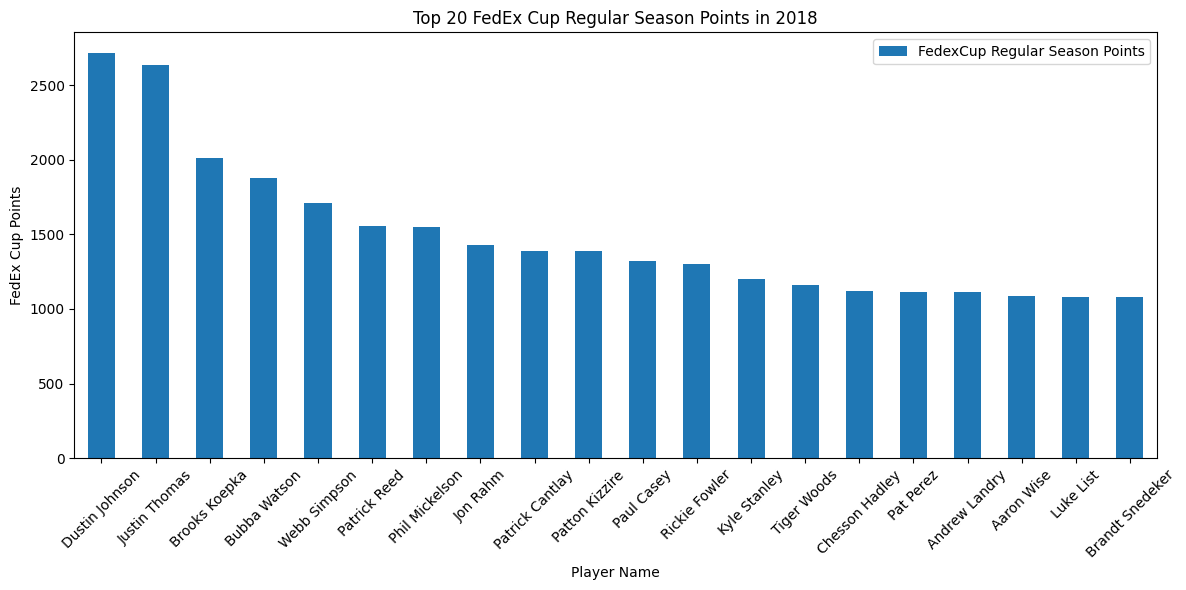

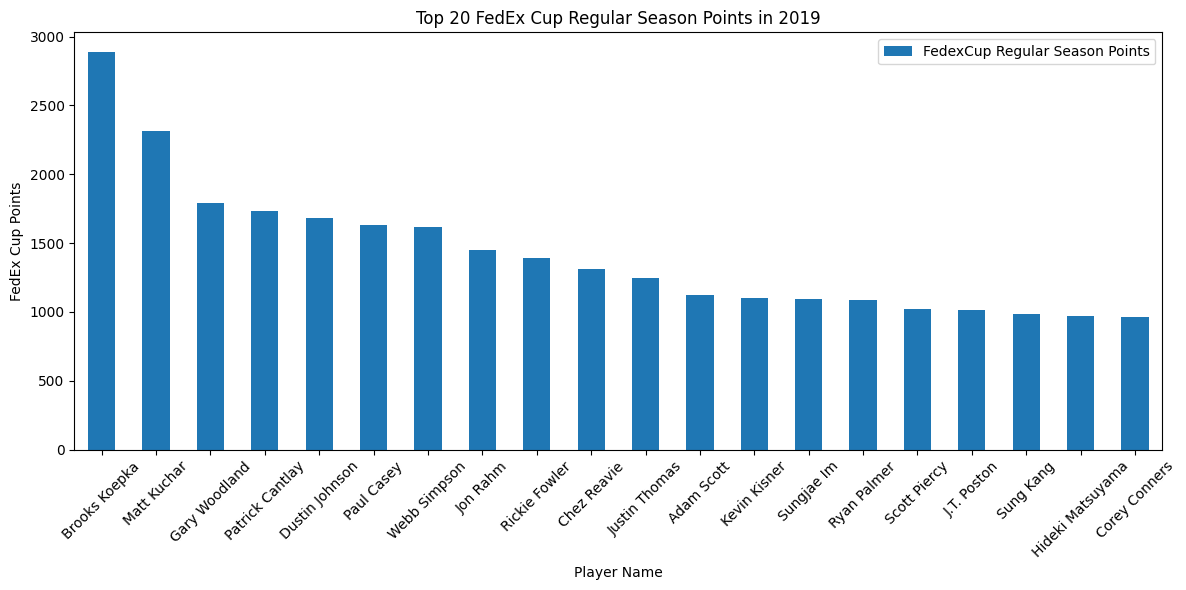

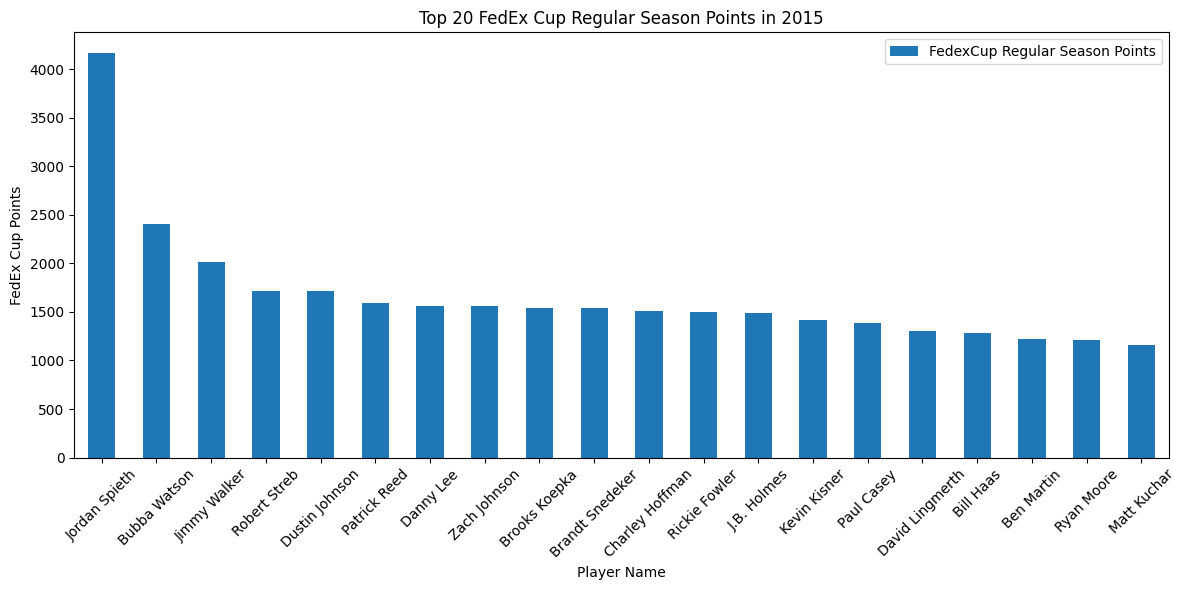

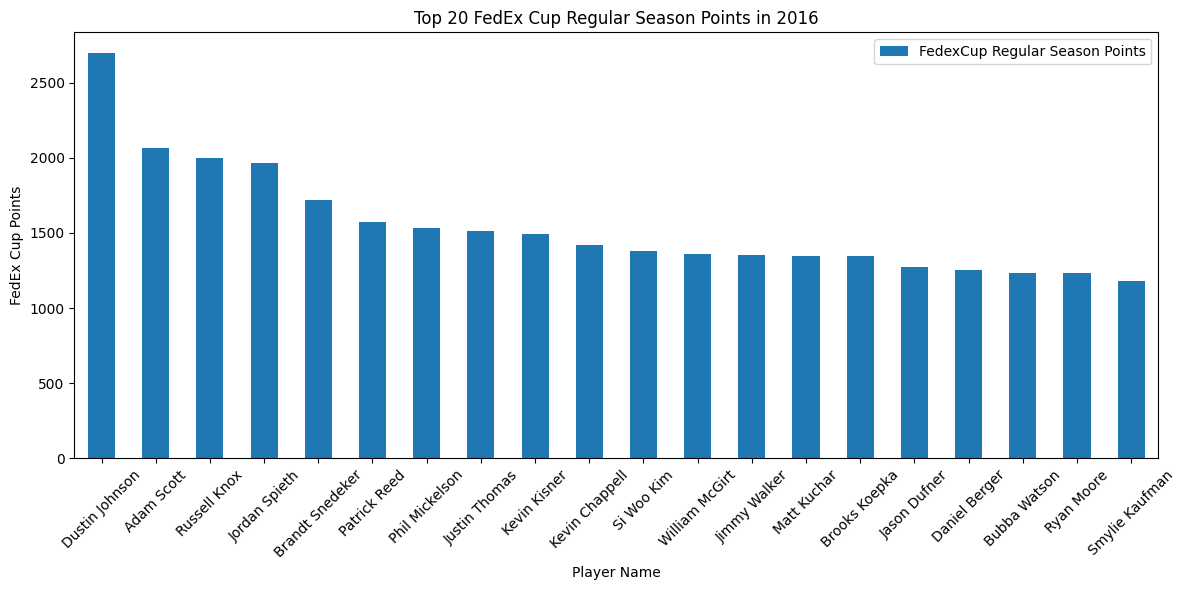

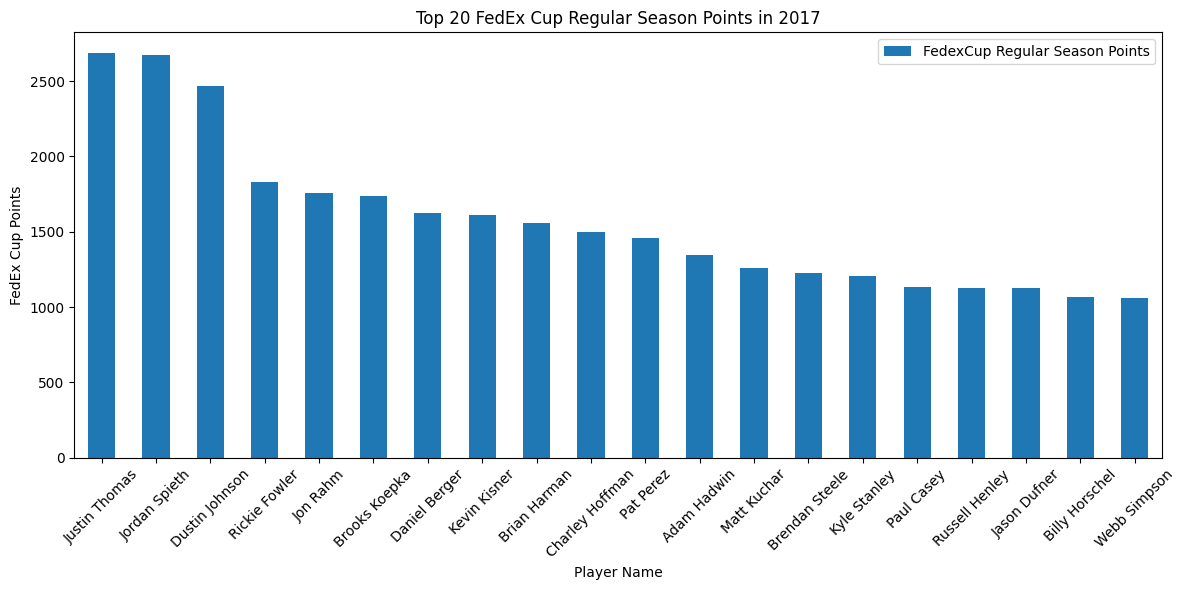

In [ ]:
# Find unique years
years_span = df_analysis['Season'].unique()

# Copy the DataFrame for a sorted FEDEX cup graphic
df_sorted_FEDEX = df_analysis.copy()

for year in years_span:
    # Filter for the 2015 season
    df_year = df_sorted_FEDEX[df_sorted_FEDEX['Season'] == year]

    # Sort the filtered DataFrame and get the top 20 players
    df_top_20 = df_year.sort_values(by='FedexCup Regular Season Points', ascending=False).head(20)

    # Plotting
    df_top_20.plot(kind='bar', x='PLAYER NAME', y='FedexCup Regular Season Points', figsize=(12, 6))

    # Show plot
    plt.title(f'Top 20 FedEx Cup Regular Season Points in {year}')
    plt.xlabel('Player Name')
    plt.ylabel('FedEx Cup Points')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



# Part 3: Building our Machine Learning Model

In this section, we will attempt to define the factors that influence a top-10 finish. Naturally, Fed Ex Cup points and Money made are the strongest correlates. However, to qualify for points and money, a player typically has to finish in the top $10$, so this model is inherently flawed. We have kept it for visualization and process purposes.

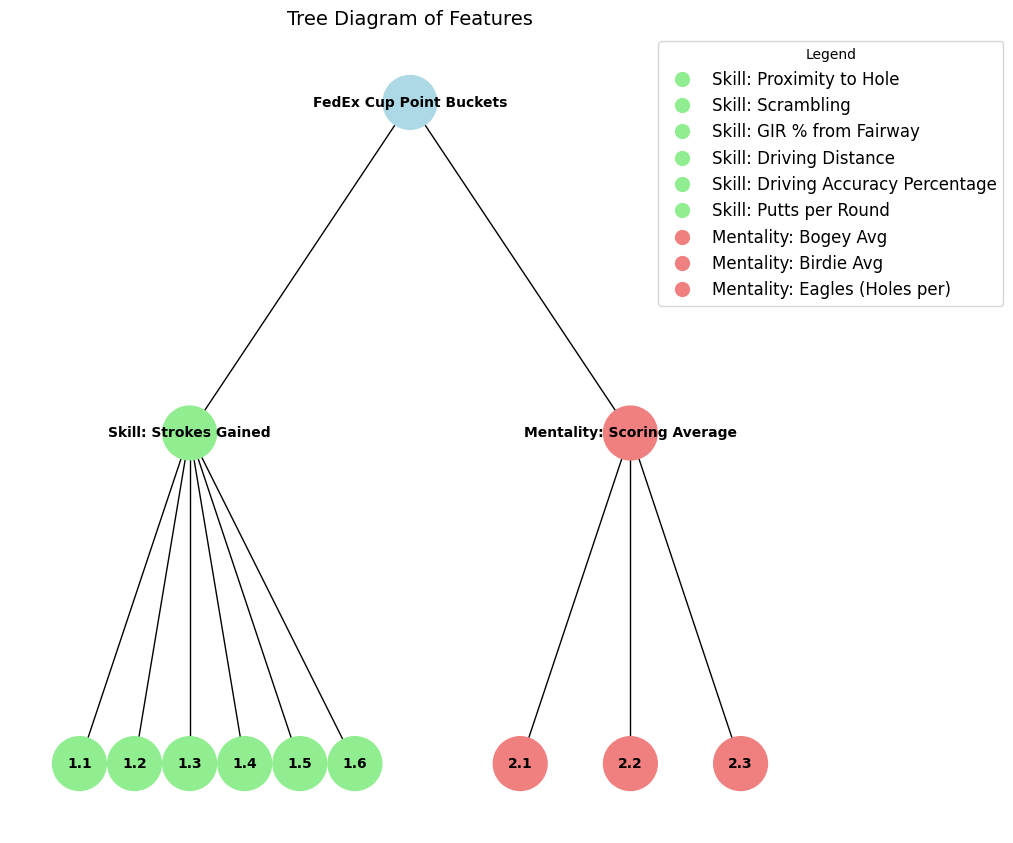

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def create_three_layered_tree():
    # Create a directed graph
    tree = nx.DiGraph()

    # Add nodes and edges for the three-layer tree structure
    tree.add_edges_from([
        # Root to 2 nodes in the second row
        ('FedEx Cup Point Buckets', 'Skill: Strokes Gained'),
        ('FedEx Cup Point Buckets', 'Mentality: Scoring Average'),

        # Node 1 connects to 6 nodes below it
        ('Skill: Strokes Gained', '1.1'),
        ('Skill: Strokes Gained', '1.2'),
        ('Skill: Strokes Gained', '1.3'),
        ('Skill: Strokes Gained', '1.4'),
        ('Skill: Strokes Gained', '1.5'),
        ('Skill: Strokes Gained', '1.6'),

        # Node 2 connects to 3 nodes below it
        ('Mentality: Scoring Average', '2.1'),
        ('Mentality: Scoring Average', '2.2'),
        ('Mentality: Scoring Average', '2.3')
    ])

    # Define the colors for each group of nodes
    node_colors = {
        'FedEx Cup Point Buckets': 'lightblue',
        'Skill: Strokes Gained': 'lightgreen',  # Color for the node itself
        '1.1': 'lightgreen', '1.2': 'lightgreen', '1.3': 'lightgreen',
        '1.4': 'lightgreen', '1.5': 'lightgreen', '1.6': 'lightgreen',
        'Mentality: Scoring Average': 'lightcoral',  # Color for the node itself
        '2.1': 'lightcoral', '2.2': 'lightcoral', '2.3': 'lightcoral'
    }

    # Generate the layout to visualize the tree in layers with improved spacing
    pos = {
        'FedEx Cup Point Buckets': (0, 3),  # Root at the top
        'Skill: Strokes Gained': (-2, 2), 'Mentality: Scoring Average': (2, 2),  # Second row with more spacing
        '1.1': (-3, 1), '1.2': (-2.5, 1), '1.3': (-2, 1), '1.4': (-1.5, 1),
        '1.5': (-1, 1), '1.6': (-0.5, 1),  # Third row under Node 1 with more spacing
        '2.1': (1, 1), '2.2': (2, 1), '2.3': (3, 1)  # Third row under Node 2 with more spacing
    }

    # Get the colors for each node
    colors = [node_colors[node] for node in tree.nodes()]

    # Draw the tree with specific layout
    plt.figure(figsize=(8, 8))  # Taller and skinnier figure
    nx.draw(tree, pos, with_labels=True, node_size=1500, node_color=colors, font_size=10, font_weight='bold', arrows=False)

    # Create a legend with node names
    legend_labels = {
        '1.1': 'Skill: Proximity to Hole',
        '1.2': 'Skill: Scrambling',
        '1.3': 'Skill: GIR % from Fairway',
        '1.4': 'Skill: Driving Distance',
        '1.5': 'Skill: Driving Accuracy Percentage',
        '1.6': 'Skill: Putts per Round',
        '2.1': 'Mentality: Bogey Avg',
        '2.2': 'Mentality: Birdie Avg',
        '2.3': 'Mentality: Eagles (Holes per)'
    }

    # Create a legend with custom labels
    handles = [plt.Line2D([0], [0], marker='o', color='w', label=legend_labels[node],
                          markerfacecolor=node_colors[node], markersize=12) for node in legend_labels.keys()]

    # Increase legend font size and marker size
    plt.legend(handles=handles, title="Legend", loc='upper left', bbox_to_anchor=(0.8, 1), prop={'size': 12})

    # Show the tree diagram
    plt.title("Tree Diagram of Features", fontsize=14)
    plt.axis('off')  # Hide the axes for better visual appeal
    plt.show()

# Call the function to create and display the tree
create_three_layered_tree()



In [ ]:
df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 580 entries, 2 to 1480
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   PLAYER NAME                     580 non-null    object 
 1   Ball Speed                      580 non-null    float64
 2   Driving Distance                580 non-null    float64
 3   Approaches from > 100 yards     580 non-null    float64
 4   Eagles (Holes per)              580 non-null    float64
 5   Putts Per Round                 580 non-null    float64
 6   Birdie Average                  580 non-null    float64
 7   Proximity to Hole               580 non-null    float64
 8   FedexCup Regular Season Points  580 non-null    float64
 9   Average Distance of Putts made  580 non-null    float64
 10  GIR Percentage from Fairway     580 non-null    float64
 11  Official Money                  580 non-null    int64  
 12  Bogey Average                   580 non-

number of rows after dropping NaNs: 580


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_

Accuracy: 0.00

Confusion Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 1 0]]

Classification Report:
              precision    recall  f1-score   support

       124.0       0.00      0.00      0.00       1.0
       140.0       0.00      0.00      0.00       1.0
       187.0       0.00      0.00      0.00       1.0
       188.0       0.00      0.00      0.00       0.0
       209.0       0.00      0.00      0.00       1.0
       222.0       0.00      0.00      0.00       0.0
       223.0       0.00      0.00      0.00       1.0
       225.0       0.00      0.00      0.00       1.0
       232.0       0.00      0.00      0.00       1.0
       234.0       0.00      0.00      0.00       1.0
       239.0       0.00      0.00      0.00       1.0
       255.0       0.00      0.00      0.00       0.0
       265.0       0.00      0.00      0.00       0.0
       266.0       0.00      0.00      0.00       2.0
       267.

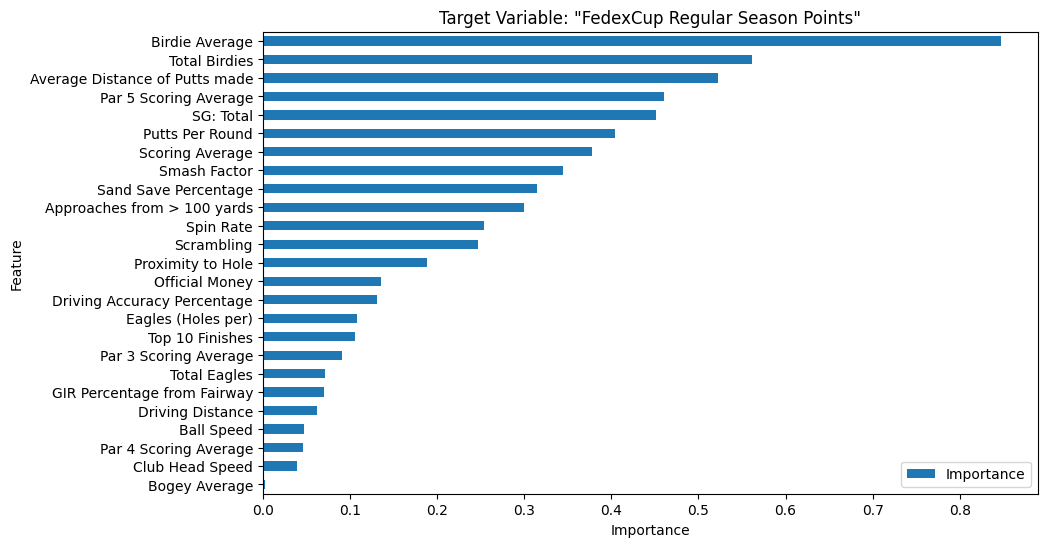

In [ ]:
df_ML = df_analysis.copy()

# Define the dependent variable and features
target_var = 'FedexCup Regular Season Points'
features = [
    'Ball Speed',
    'Driving Distance',
    'Approaches from > 100 yards',
    'Eagles (Holes per)',
    'Putts Per Round',
    'Birdie Average',
    'Proximity to Hole',
    'Top 10 Finishes',
    'Average Distance of Putts made',
    'GIR Percentage from Fairway',
    'Official Money',
    'Bogey Average',
    'Par 3 Scoring Average',
    'Club Head Speed',
    'Par 4 Scoring Average',
    'Par 5 Scoring Average',
    'Driving Accuracy Percentage',
    'Scoring Average',
    'Total Birdies',
    'Total Eagles',
    'Spin Rate',
    'Sand Save Percentage',
    'Scrambling',
    'SG: Total',
    'Smash Factor',
]

df_ML = df_ML.dropna(subset=features + [target_var])
print('number of rows after dropping NaNs:', len(df_ML))

df_model = df_ML.copy()

def logistic_regression_analysis(df_ML, target_var, features):
    # Select relevant data
    X = df_ML[features]
    y = df_ML[target_var]

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Standardize the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train sklearn's logistic regression model
    model = LogisticRegression(max_iter=1000, solver='lbfgs')
    model.fit(X_train_scaled, y_train)

    # Use this to make predictions on the test set
    y_pred = model.predict(X_test_scaled)

    # Evaluate performance
    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    classification_rep = classification_report(y_test, y_pred)

    print(f"Accuracy: {accuracy:.2f}\n")
    print("Confusion Matrix:")
    print(conf_matrix)
    print("\nClassification Report:")
    print(classification_rep)

    # Examine feature importance
    coefficients = model.coef_[0]

    feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': abs(coefficients)})
    feature_importance = feature_importance.sort_values('Importance', ascending=True)

    # Create the horizontal bar plot
    ax = feature_importance.plot(x='Feature', y='Importance', kind='barh', figsize=(10, 6))

    # Add a title to the plot
    plt.title(f'Target Variable: "{target_var}"')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()

logistic_regression_analysis(df_ML, target_var, features)

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_

Accuracy: 0.00

Confusion Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 1 0 0]]

Classification Report:
              precision    recall  f1-score   support

      294536       0.00      0.00      0.00       1.0
      309588       0.00      0.00      0.00       1.0
      373092       0.00      0.00      0.00       1.0
      404377       0.00      0.00      0.00       0.0
      411606       0.00      0.00      0.00       0.0
      418963       0.00      0.00      0.00       1.0
      443006       0.00      0.00      0.00       0.0
      449226       0.00      0.00      0.00       0.0
      454296       0.00      0.00      0.00       1.0
      457337       0.00      0.00      0.00       1.0
      474923       0.00      0.00      0.00       1.0
      490976       0.00      0.00      0.00       1.0
      494795       0.00      0.00      0.00       1.0
      498341       0.00      0.00      0.00       0.0
      53293

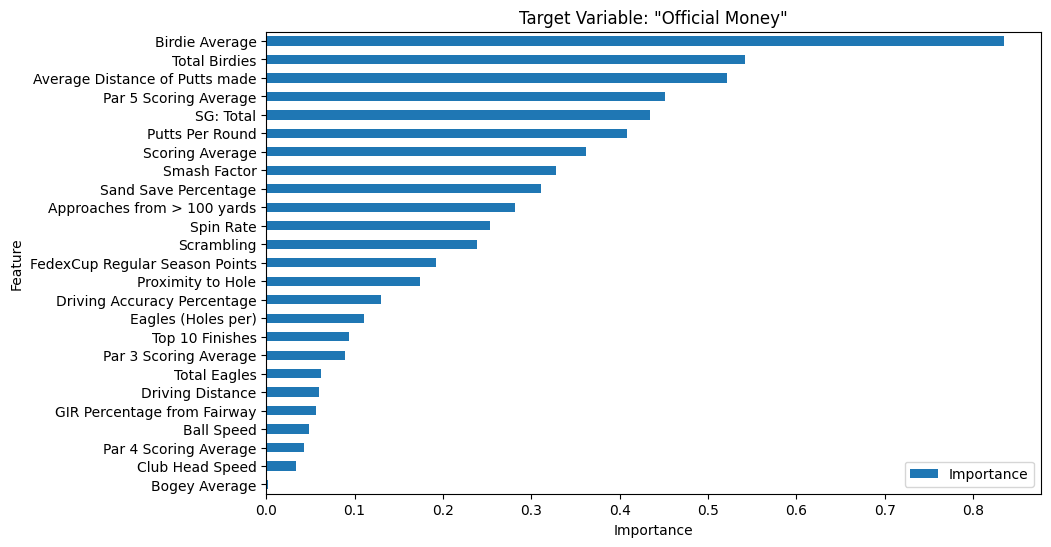

In [ ]:
target_var = 'Official Money'
features = [
    'Ball Speed',
    'Driving Distance',
    'Approaches from > 100 yards',
    'Eagles (Holes per)',
    'Putts Per Round',
    'Birdie Average',
    'Proximity to Hole',
    'Top 10 Finishes',
    'Average Distance of Putts made',
    'GIR Percentage from Fairway',
    'FedexCup Regular Season Points',
    'Bogey Average',
    'Par 3 Scoring Average',
    'Club Head Speed',
    'Par 4 Scoring Average',
    'Par 5 Scoring Average',
    'Driving Accuracy Percentage',
    'Scoring Average',
    'Total Birdies',
    'Total Eagles',
    'Spin Rate',
    'Sand Save Percentage',
    'Scrambling',
    'SG: Total',
    'Smash Factor',
]


logistic_regression_analysis(df_ML, target_var, features)

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_

Accuracy: 0.34

Confusion Matrix:
[[18  6  2  0  0  0  0  0  0  0  0  0]
 [12  9  6  2  0  1  0  0  0  0  0  0]
 [ 4  9  5  4  0  1  0  0  0  0  0  0]
 [ 0  3  5  6  1  0  0  0  0  0  0  0]
 [ 0  0  2  4  0  2  0  0  0  0  0  0]
 [ 0  1  0  1  1  1  0  0  0  0  0  0]
 [ 0  0  0  0  1  2  0  1  0  0  0  0]
 [ 0  0  0  1  1  0  0  0  1  1  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  1  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  1]
 [ 0  0  0  0  0  0  0  0  0  0  0  0]]

Classification Report:
              precision    recall  f1-score   support

         1.0       0.53      0.69      0.60        26
         2.0       0.32      0.30      0.31        30
         3.0       0.25      0.22      0.23        23
         4.0       0.33      0.40      0.36        15
         5.0       0.00      0.00      0.00         8
         6.0       0.12      0.25      0.17         4
         7.0       0.00      0.00      0.00         4
         8.0       0.00      0.00      0

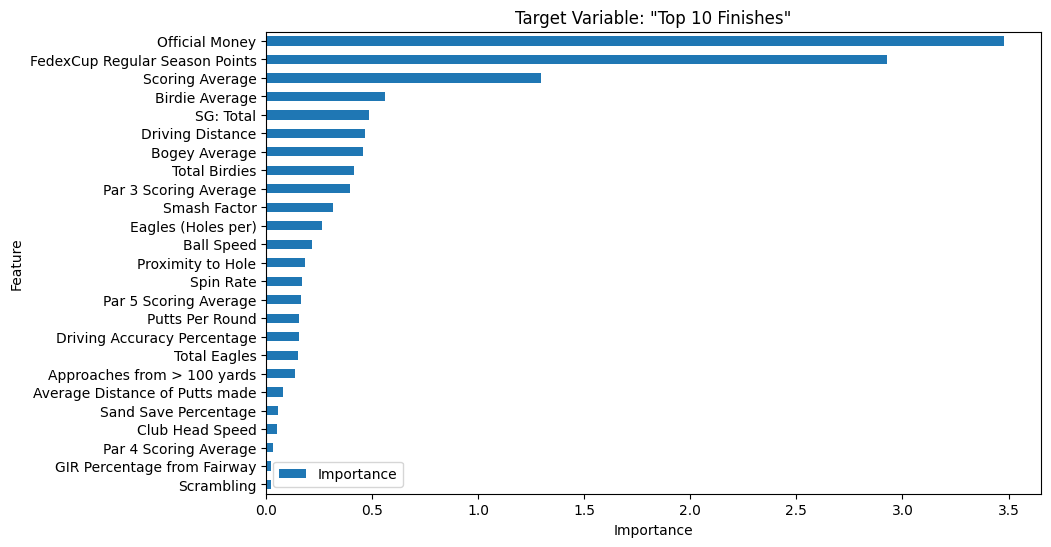

In [ ]:
target_var = 'Top 10 Finishes'
features = [
    'Ball Speed',
    'Driving Distance',
    'Approaches from > 100 yards',
    'Eagles (Holes per)',
    'Putts Per Round',
    'Birdie Average',
    'Proximity to Hole',
    'FedexCup Regular Season Points',
    'Average Distance of Putts made',
    'GIR Percentage from Fairway',
    'Official Money',
    'Bogey Average',
    'Par 3 Scoring Average',
    'Club Head Speed',
    'Par 4 Scoring Average',
    'Par 5 Scoring Average',
    'Driving Accuracy Percentage',
    'Scoring Average',
    'Total Birdies',
    'Total Eagles',
    'Spin Rate',
    'Sand Save Percentage',
    'Scrambling',
    'SG: Total',
    'Smash Factor',
]

logistic_regression_analysis(df_ML, target_var, features)

# Part 4: Investigating Scoring Average

Now, we want to examine another way to predict the strength of a golfer.
Our Top-10 above is very outcome focused, which we find to often be misleading in golf
Golf is particularly random - and though all golfer's goal is to win as many events as possible,
many understand that improving their game independently of outcome focus will be the most direct
way to increase their probability of victory. Therefore, since we have the "Strokes Gained" metric,
which measures how many strokes the golfer is improved over par in a given round. This is a better
process oriented approach, and we believe that using this as the target variable (and seeing which
golfer intrinsic statistics are of most importance) is the most telling story.

R-squared: 0.4734288909931833, Mean Squared Error: 0.19282991051868123


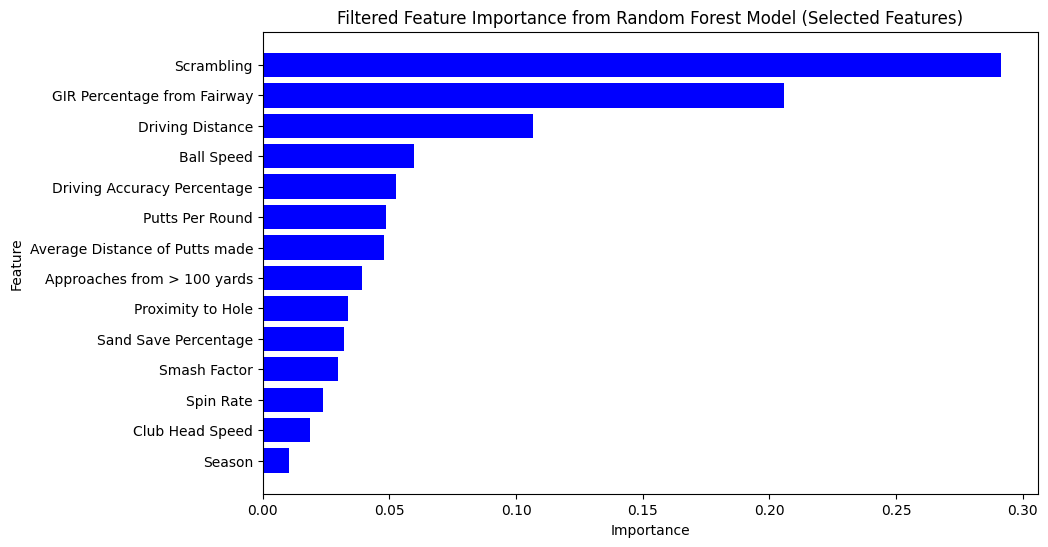

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

# Filter the dataset to only include rows where the season is 2015, 2016, or 2017
df_filtered_seasons = df_ML[df_ML['Season'].isin([2015, 2016, 2017, 2018])]

# Define X and y based on the filtered data, keeping 'Season' if desired or dropping it
X = df_filtered_seasons.drop(columns=['SG: Total'])
y = df_filtered_seasons['SG: Total']

# Define the list of features you want to include in the regression as a list
X_filtered = ['Scrambling', 'GIR Percentage from Fairway', 'Driving Distance',
              'Putts Per Round', 'Sand Save Percentage', 'Driving Accuracy Percentage',
              'Approaches from > 100 yards', 'Ball Speed', 'Proximity to Hole',
              'Spin Rate', 'Club Head Speed', 'Average Distance of Putts made', 'Smash Factor', 'Season']

# Filter the dataset to only include the selected features
X_train_filtered, X_test_filtered, y_train, y_test = train_test_split(X[X_filtered], y, test_size=0.2, random_state=42)

# Standardizing the filtered features
scaler = StandardScaler()
X_train_scaled_filtered = scaler.fit_transform(X_train_filtered)
X_test_scaled_filtered = scaler.transform(X_test_filtered)

# Re-training the Random Forest Regressor model
rf_model_filtered = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_filtered.fit(X_train_scaled_filtered, y_train)

# Making predictions on the test set
y_pred = rf_model_filtered.predict(X_test_scaled_filtered)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f'R-squared: {r2}, Mean Squared Error: {mse}')

# Extracting the feature importances for the filtered features
filtered_feature_importances = rf_model_filtered.feature_importances_

# Sorting and plotting the feature importance
sorted_idx_filtered = np.argsort(filtered_feature_importances)[::-1]
sorted_importances_filtered = filtered_feature_importances[sorted_idx_filtered]
sorted_features_filtered = np.array(X_filtered)[sorted_idx_filtered]

# Plotting the filtered feature importance
plt.figure(figsize=(10, 6))
plt.barh(sorted_features_filtered, sorted_importances_filtered, color='blue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Filtered Feature Importance from Random Forest Model (Selected Features)')
plt.gca().invert_yaxis()
plt.show()


Iterating on this idea, we see that many of these are heavily correlated. For example, club head speed is a near perfect predictor of driving distance. Therefore, we are going to include only the most "important" of these metrics that contribute to the following golf attributes:

Distance: Driving Distance

Driving Accuracy: Dirving Accuracy Percentage

Approach Shots: GIR Percentage from Fairway

Wedge Play: Proximinty to Hole

Short Game: Scrambling

Putting: Putts per round


R-squared: 0.46282892367333106, Mean Squared Error: 0.1967116099032967


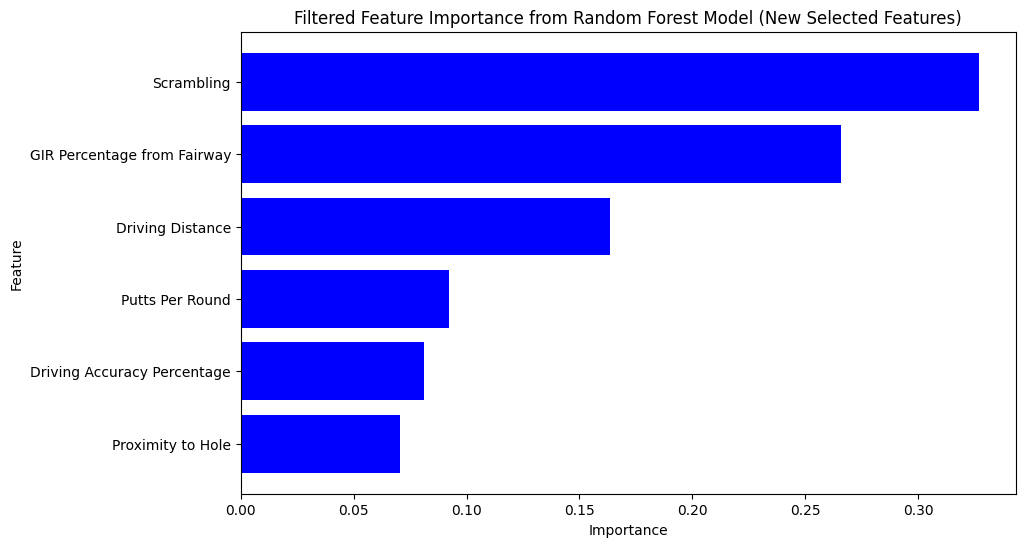

In [ ]:
# Define the new list of features for the second regression
X_filtered_new = ['Driving Distance', 'Driving Accuracy Percentage', 'GIR Percentage from Fairway',
                  'Proximity to Hole', 'Scrambling', 'Putts Per Round']

# Run the same process as before, but now using only these features
X_train_filtered_new, X_test_filtered_new, y_train, y_test = train_test_split(X[X_filtered_new], y, test_size=0.2, random_state=42)

# Standardizing the filtered features
X_train_scaled_filtered_new = scaler.fit_transform(X_train_filtered_new)
X_test_scaled_filtered_new = scaler.transform(X_test_filtered_new)

# Re-training the Random Forest Regressor model with the new set of features
rf_model_filtered_new = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_filtered_new.fit(X_train_scaled_filtered_new, y_train)

# Making predictions on the test set
y_pred_new = rf_model_filtered_new.predict(X_test_scaled_filtered_new)

# Model performance evaluation
r2_new = r2_score(y_test, y_pred_new)
mse_new = mean_squared_error(y_test, y_pred_new)
print(f'R-squared: {r2_new}, Mean Squared Error: {mse_new}')

# Extracting the feature importances for the new filtered features
filtered_feature_importances_new = rf_model_filtered_new.feature_importances_

# Sorting and plotting the feature importance
sorted_idx_filtered_new = np.argsort(filtered_feature_importances_new)[::-1]
sorted_importances_filtered_new = filtered_feature_importances_new[sorted_idx_filtered_new]
sorted_features_filtered_new = np.array(X_filtered_new)[sorted_idx_filtered_new]

# Plotting the filtered feature importance
plt.figure(figsize=(10, 6))
plt.barh(sorted_features_filtered_new, sorted_importances_filtered_new, color='blue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Filtered Feature Importance from Random Forest Model (New Selected Features)')
plt.gca().invert_yaxis()
plt.show()


In [ ]:
# Define the new list of features for the second regression
X_filtered_new = ['Driving Distance', 'Driving Accuracy Percentage', 'GIR Percentage from Fairway',
                  'Proximity to Hole', 'Scrambling', 'Putts Per Round']

# Run the same process as before, but now using only these features
X_train_filtered_new, X_test_filtered_new, y_train, y_test = train_test_split(X[X_filtered_new], y, test_size=0.2, random_state=42)

# Standardizing the filtered features
X_train_scaled_filtered_new = scaler.fit_transform(X_train_filtered_new)
X_test_scaled_filtered_new = scaler.transform(X_test_filtered_new)

# Re-training the Random Forest Regressor model with the new set of features
rf_model_filtered_new = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_filtered_new.fit(X_train_scaled_filtered_new, y_train)

# Making predictions on the test set
y_pred_new = rf_model_filtered_new.predict(X_test_scaled_filtered_new)

# Model performance evaluation
r2_new = r2_score(y_test, y_pred_new)
mse_new = mean_squared_error(y_test, y_pred_new)
print(f'R-squared: {r2_new}, Mean Squared Error: {mse_new}')

# Extracting the feature importances for the new filtered features
filtered_feature_importances_new = rf_model_filtered_new.feature_importances_

# Sorting the feature importance and storing the values
sorted_idx_filtered_new = np.argsort(filtered_feature_importances_new)[::-1]
sorted_importances_filtered_new = filtered_feature_importances_new[sorted_idx_filtered_new]
sorted_features_filtered_new = np.array(X_filtered_new)[sorted_idx_filtered_new]

# Storing the importance values for each feature as a dictionary
SG_feature_importance_dict = dict(zip(sorted_features_filtered_new, sorted_importances_filtered_new))

# Output the stored importance values
print("Feature Importances (as decimal values):")
for feature, importance in SG_feature_importance_dict.items():
    print(f'{feature}: {importance:.4f}')

R-squared: 0.46282892367333106, Mean Squared Error: 0.1967116099032967
Feature Importances (as decimal values):
Scrambling: 0.3269
GIR Percentage from Fairway: 0.2658
Driving Distance: 0.1634
Putts Per Round: 0.0923
Driving Accuracy Percentage: 0.0810
Proximity to Hole: 0.0706


This gives us a fairly surprising, yet indicative result. It shows that for golfers to increase their innate playing ability (as measured by SG: Total), they should focus most on their short game and long iron play (shots outside of their wedges to hit the green). Then, driving power and putting to a lesser degree. Then, to the least amount of importance, wedge play and driving accuracy.

Since we have now defined the key contributing factors to SG: Total, let's examine how truly predictive it is of success on the PGA Tour. Let's define success by a few different outcome variables: FedEx Points (how the PGA Seeds into the playoffs), Official Money earned (tiered payout system by final rank in each tournament is another great proxy for tournament success), and finally Top-10's.

FedEx Points:
  R-squared: 0.55
  Mean Squared Error: 107132.95


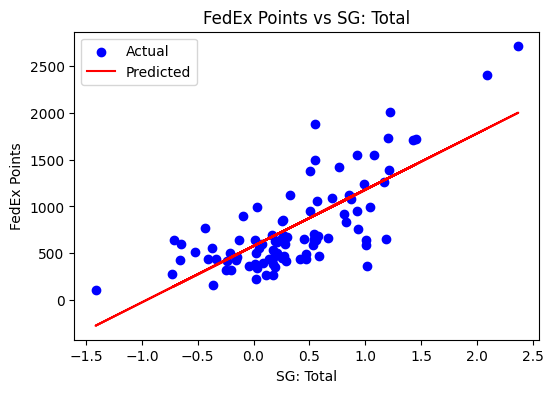

Official Money:
  R-squared: 0.54
  Mean Squared Error: 1227196256801.11


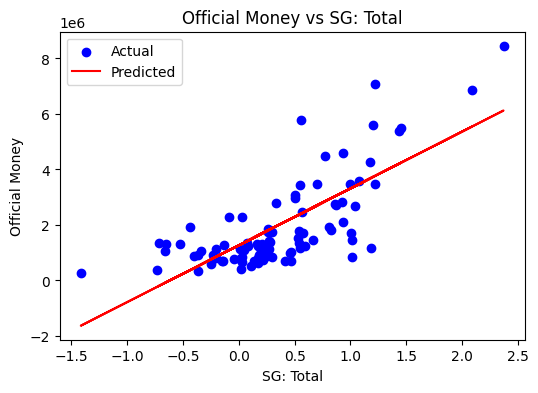

Top 10 Finishes:
  R-squared: 0.50
  Mean Squared Error: 2.95


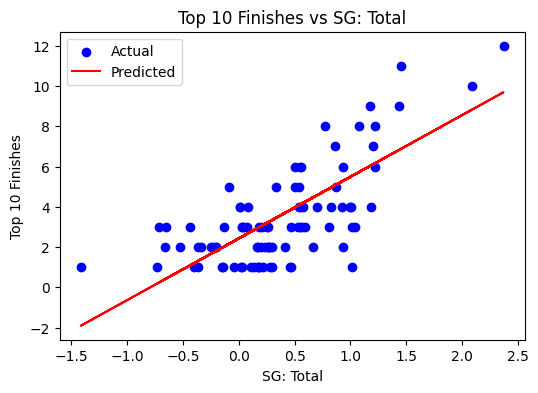

In [ ]:
from sklearn.linear_model import LinearRegression

# Define the feature (SG: Total) and the three outcome variables
X_sg_total = df_filtered_seasons[['SG: Total']]

# Outcome variables
y_fedex = df_filtered_seasons['FedexCup Regular Season Points']
y_money = df_filtered_seasons['Official Money']
y_top10 = df_filtered_seasons['Top 10 Finishes']

# List to store model results
outcomes = {'FedEx Points': y_fedex, 'Official Money': y_money, 'Top 10 Finishes': y_top10}

# Loop through the outcomes and run a model for each
for outcome_name, y_outcome in outcomes.items():
    # Split into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_sg_total, y_outcome, test_size=0.2, random_state=42)

    # Linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate performance
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    # Print results
    print(f'{outcome_name}:')
    print(f'  R-squared: {r2:.2f}')
    print(f'  Mean Squared Error: {mse:.2f}')

    # Plot the results
    plt.figure(figsize=(6, 4))
    plt.scatter(X_test, y_test, color='blue', label='Actual')
    plt.plot(X_test, y_pred, color='red', label='Predicted')
    plt.title(f'{outcome_name} vs SG: Total')
    plt.xlabel('SG: Total')
    plt.ylabel(outcome_name)
    plt.legend()
    plt.show()


These show promising results in how predictive SG: Total is to outcome focused variables.

Finally, we want to look at what can be considered an outcome variable (scoring average) and see how much this translates to winning. But similar to our analysis of SG: Total, we first want to see the biggest contributors to Scoring Average from a round performance perspective. This ideation comes from the separation of skill as a golfer (ie how good you are at driving the ball, hitting irons, putting, etc.) that contributes directly to SG: Total from the skill of scoring (converting on your chances, limiting bad holes) that all golfers attribute more to the mental part of the sport.

Therefore, we will first look at the in-round outcome variables that contribute the most to scoring average.

R-squared for Scoring Average prediction: 0.75


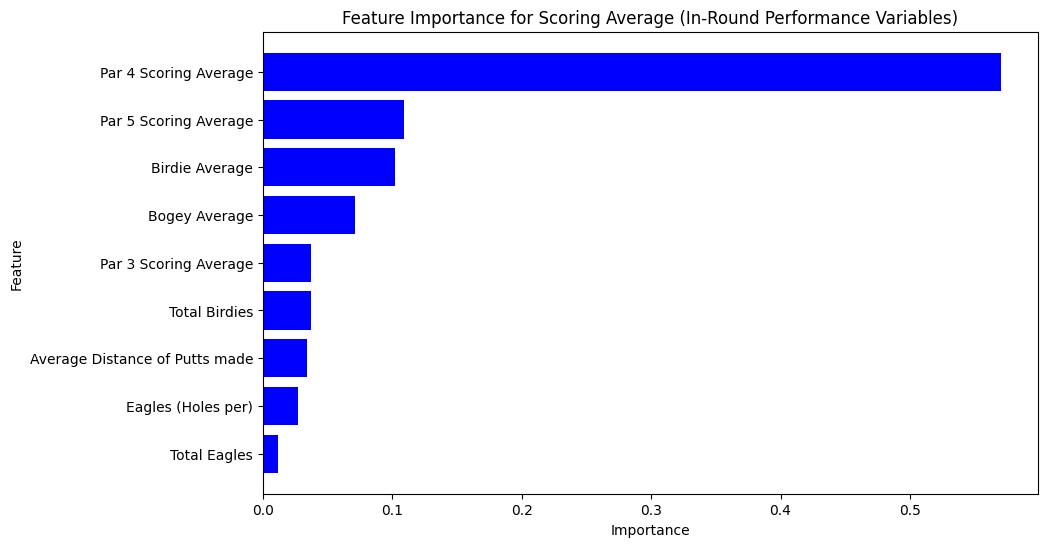

In [ ]:
# Define the in-round outcome variables
X_round_performance = df_filtered_seasons[['Eagles (Holes per)', 'Birdie Average', 'Average Distance of Putts made',
                             'Bogey Average', 'Par 3 Scoring Average', 'Par 4 Scoring Average',
                             'Par 5 Scoring Average', 'Total Birdies', 'Total Eagles']]

# Define the target variable (Scoring Average)
y_scoring_average = df_filtered_seasons['Scoring Average']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_round_performance, y_scoring_average, test_size=0.2, random_state=42)

# Train a Random Forest Regressor
rf_model_scoring = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_scoring.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model_scoring.predict(X_test)

# Evaluate the performance (R-squared)
r2 = r2_score(y_test, y_pred)
print(f'R-squared for Scoring Average prediction: {r2:.2f}')

# Extract feature importance
feature_importances = rf_model_scoring.feature_importances_

# Sort and plot the feature importance
sorted_idx = np.argsort(feature_importances)[::-1]
sorted_importances = feature_importances[sorted_idx]
sorted_features = X_round_performance.columns[sorted_idx]

# Plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(sorted_features, sorted_importances, color='blue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for Scoring Average (In-Round Performance Variables)')
plt.gca().invert_yaxis()
plt.show()


This result is heavily surprising to us. The reason for the discrepancy in our original important features graph is that the target variable is now average scoring, as compared to top 10s. Many people believe that the key to **winning** on the PGA Tour is to birdie as many Par 5's as possible, so the importance of Par 4 average to us was surprising but can likely be explained by two different reasons:

1. There are ~11-12 Par 4's on an 18 hole course, meaning the performance on Par 4's is simply significantly more important because it is $\frac{2}{3}$ of the round.

2. To this end, let's try and remove this implicit weight by excluding scoring averages per type of hole, and looking at overall in round scoring (while removing redundancies like total birdies vs average birdies).

R-squared for Scoring Average prediction: 0.55


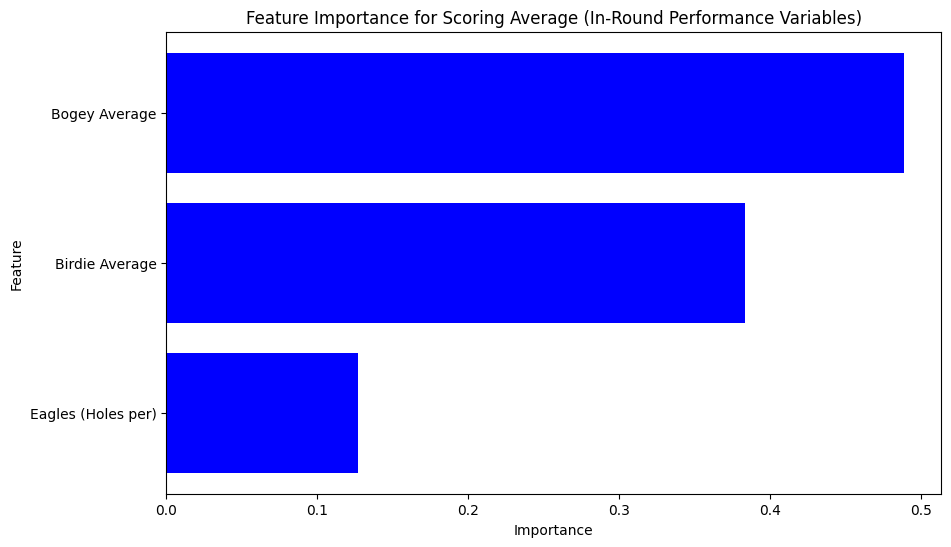

In [ ]:
# Define the in-round outcome variables
X_round_performance = df_filtered_seasons[['Eagles (Holes per)', 'Birdie Average', 'Bogey Average']]

# Define the target variable (Scoring Average)
y_scoring_average = df_filtered_seasons['Scoring Average']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_round_performance, y_scoring_average, test_size=0.2, random_state=42)

# Train a Random Forest Regressor
rf_model_scoring = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_scoring.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model_scoring.predict(X_test)

# Evaluate the performance (R-squared)
r2 = r2_score(y_test, y_pred)
print(f'R-squared for Scoring Average prediction: {r2:.2f}')

# Extract feature importance
feature_importances = rf_model_scoring.feature_importances_

# Sort and plot the feature importance
sorted_idx = np.argsort(feature_importances)[::-1]
sorted_importances = feature_importances[sorted_idx]
sorted_features = X_round_performance.columns[sorted_idx]

# Plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(sorted_features, sorted_importances, color='blue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for Scoring Average (In-Round Performance Variables)')
plt.gca().invert_yaxis()
plt.show()


In [ ]:
# Define the in-round outcome variables
X_round_performance = df_filtered_seasons[['Eagles (Holes per)', 'Birdie Average', 'Bogey Average']]

# Define the target variable (Scoring Average)
y_scoring_average = df_filtered_seasons['Scoring Average']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_round_performance, y_scoring_average, test_size=0.2, random_state=42)

# Train a Random Forest Regressor
rf_model_scoring = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_scoring.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model_scoring.predict(X_test)

# Evaluate the performance (R-squared)
r2 = r2_score(y_test, y_pred)
print(f'R-squared for Scoring Average prediction: {r2:.2f}')

# Extract feature importance
feature_importances = rf_model_scoring.feature_importances_

# Sort the feature importance and store the values
sorted_idx = np.argsort(feature_importances)[::-1]
sorted_importances = feature_importances[sorted_idx]
sorted_features = X_round_performance.columns[sorted_idx]

# Storing the feature importance values as a dictionary
avg_feature_importance_dict = dict(zip(sorted_features, sorted_importances))

# Output the stored importance values
print("Feature Importances (as decimal values):")
for feature, importance in avg_feature_importance_dict.items():
    print(f'{feature}: {importance:.4f}')

R-squared for Scoring Average prediction: 0.55
Feature Importances (as decimal values):
Bogey Average: 0.4892
Birdie Average: 0.3839
Eagles (Holes per): 0.1269


This result makes a lot more sense. Remember, our target variable here is in fact scoring **average**. Therefore, we see that limiting mistakes (bogeys) is even more important than capturing upside (birdies). Side note: Eagles, by in large, are very rare and normally occur once every few rounds. This ties very heavily that scoring average is driven by mental fortitude, and limiting mistakes. Therefore, we have established two principles:

1. SG: Total is a measure of how good a golfer is - which is driven by how good a golfer primarily is at capitalizing on opportunity.

2. Scoring Average is a measure of how strong a golfer's mental fortitude is - the talent on the PGA Tour level is so strong that the difference in limiting mistakes, which we found to be the key driver here, is not a difference in skill but one of differing mental approaches.

Finally, let's confirm that scoring average is in fact predictive of the three season long outcome variables as before (FedEx points, Total Money, and Top 10s).

FedEx Points:
  R-squared: 0.58
  Mean Squared Error: 101581.61


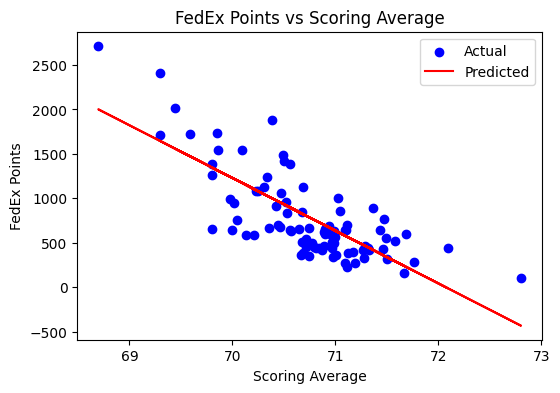

Official Money:
  R-squared: 0.57
  Mean Squared Error: 1145571221064.53


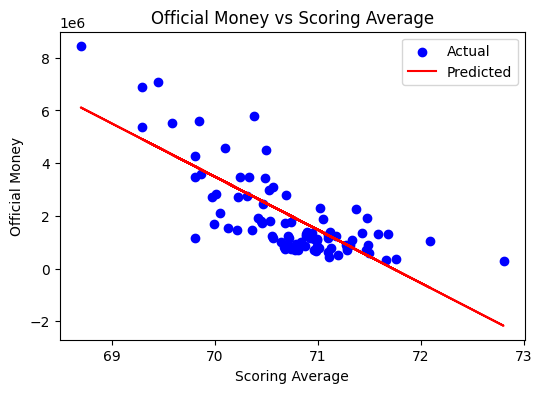

Top 10 Finishes:
  R-squared: 0.49
  Mean Squared Error: 2.96


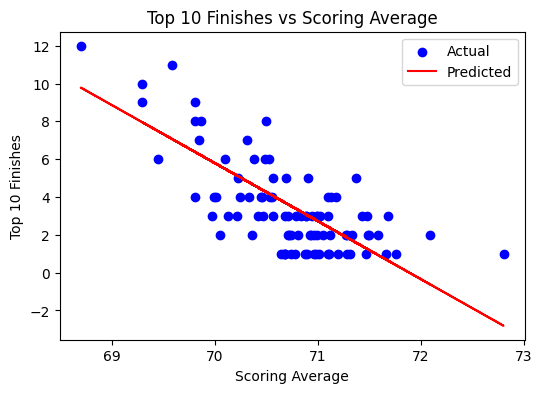

In [ ]:
# Define the feature (Scoring Average) and the three outcome variables
X_scoring_average = df_filtered_seasons[['Scoring Average']]

# Outcome variables
y_fedex = df_filtered_seasons['FedexCup Regular Season Points']
y_money = df_filtered_seasons['Official Money']
y_top10 = df_filtered_seasons['Top 10 Finishes']

# List to store model results
outcomes = {'FedEx Points': y_fedex, 'Official Money': y_money, 'Top 10 Finishes': y_top10}

# Loop through the outcomes and run a model for each
for outcome_name, y_outcome in outcomes.items():
    # Split into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_scoring_average, y_outcome, test_size=0.2, random_state=42)

    # Linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate performance
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    # Print results
    print(f'{outcome_name}:')
    print(f'  R-squared: {r2:.2f}')
    print(f'  Mean Squared Error: {mse:.2f}')

    # Plot the results
    plt.figure(figsize=(6, 4))
    plt.scatter(X_test, y_test, color='blue', label='Actual')
    plt.plot(X_test, y_pred, color='red', label='Predicted')
    plt.title(f'{outcome_name} vs Scoring Average')
    plt.xlabel('Scoring Average')
    plt.ylabel(outcome_name)
    plt.legend()
    plt.show()


Now, let's try and backout the importance of SG vs Scoring Average for us to use later as the weighted coefficients in our actual prediction model.

R-squared for Bucket Finish prediction: 0.19


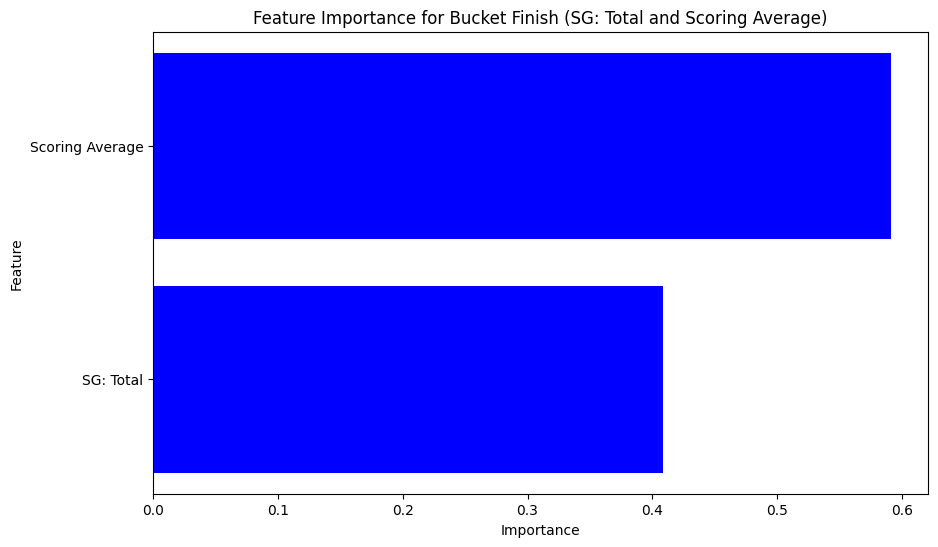

Feature Importances for Bucket Finish (SG: Total and Scoring Average):
Scoring Average: 0.5913
SG: Total: 0.4087


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Define the variables we want to test the importance on: 'SG: Total' and 'Scoring Average'
X_performance = df_filtered_seasons[['SG: Total', 'Scoring Average']]

# Define the target variable 'Bucket Finish'
y_bucket_finish = df_filtered_seasons['Top 10 Finish']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_performance, y_bucket_finish, test_size=0.2, random_state=42)

# Train a Random Forest Regressor
rf_model_bucket_finish = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_bucket_finish.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model_bucket_finish.predict(X_test)

# Evaluate the performance (R-squared)
r2_bucket = r2_score(y_test, y_pred)
print(f'R-squared for Bucket Finish prediction: {r2_bucket:.2f}')

# Extract feature importance
feature_importances_bucket = rf_model_bucket_finish.feature_importances_

# Sort and plot the feature importance
sorted_idx_bucket = np.argsort(feature_importances_bucket)[::-1]
sorted_importances_bucket = feature_importances_bucket[sorted_idx_bucket]
sorted_features_bucket = X_performance.columns[sorted_idx_bucket]

# Plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(sorted_features_bucket, sorted_importances_bucket, color='blue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for Bucket Finish (SG: Total and Scoring Average)')
plt.gca().invert_yaxis()
plt.show()

# Storing the feature importance values as a dictionary
bucket_feature_importance_bucket_dict = dict(zip(sorted_features_bucket, sorted_importances_bucket))

# Output the stored importance values
print("Feature Importances for Bucket Finish (SG: Total and Scoring Average):")
for feature, importance in bucket_feature_importance_bucket_dict.items():
    print(f'{feature}: {importance:.4f}')

Just as with SG: Total, we see that the fit is strong. As scoring average (per round) improves (is lower), total season outcomes improve. The opposite is also true. We see that these $R^2$ are actually a slightly better fit than SG: Total, meaning that in our predictive model we are going to build, we may want to favor the *mental* fortitude of the players (measured by scoring average) over their inherent skill (SG: Total).

# Part 6: Ranking based on SG: Total factors and Scoring Average Factors

Building out rankings based on factors importrance in SG: Total...

In [ ]:
from sklearn.preprocessing import MinMaxScaler

features = ['Scrambling', 'GIR Percentage from Fairway', 'Driving Distance',
    'Putts Per Round',
    'Proximity to Hole',
    'Driving Accuracy Percentage']

# Normalize data for the features
scaler = MinMaxScaler()
df_filtered_seasons[features] = scaler.fit_transform(df_filtered_seasons[features])

# Filter out players with total birdies <= 200
df_filtered_seasons = df_filtered_seasons[df_filtered_seasons['Total Birdies'] > 200]

def compute_weighted_SG_score(df, feature_importance_dict):
    # Compute weighted score for each player based on the provided feature importance dictionary
    df['Weighted_SG'] = (
        df['Scrambling'] * feature_importance_dict['Scrambling'] +
        df['GIR Percentage from Fairway'] * feature_importance_dict['GIR Percentage from Fairway'] +
        df['Driving Distance'] * feature_importance_dict['Driving Distance'] +
        df['Putts Per Round'] * feature_importance_dict['Putts Per Round'] +
        df['Proximity to Hole'] * feature_importance_dict['Proximity to Hole'] +
        df['Driving Accuracy Percentage'] * feature_importance_dict['Driving Accuracy Percentage']
    )
    return df

df_filtered_seasons = compute_weighted_SG_score(df_filtered_seasons, SG_feature_importance_dict)


# Rank players based on weighted score
df_filtered_seasons['SG_Rank'] = df_filtered_seasons['Weighted_SG'].rank(ascending=False)

# Display the top ranked players
ranked_players = df_filtered_seasons[['PLAYER NAME', 'Season', 'Weighted_SG', 'SG_Rank']].sort_values(by='SG_Rank')

<ipython-input-55-fca9ab9009fc>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_seasons[features] = scaler.fit_transform(df_filtered_seasons[features])
<ipython-input-55-fca9ab9009fc>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Weighted_SG'] = (


In [ ]:
ranked_players.head(10)

,PLAYER NAME,Season,Weighted_SG,SG_Rank
158,Brooks Koepka,2018,0.709316,1.0
1307,Tiger Woods,2018,0.707802,2.0
414,Dustin Johnson,2017,0.698370,3.0
753,Jordan Spieth,2018,0.692924,4.0
171,Bubba Watson,2015,0.688220,5.0
1041,Paul Casey,2016,0.687236,6.0
1042,Paul Casey,2017,0.686187,7.0
765,Justin Thomas,2018,0.684062,8.0
415,Dustin Johnson,2018,0.683112,9.0
503,Gary Woodland,2017,0.674164,10.0


Now, ranking based on scoring average...

In [ ]:
# Selecting relevant features for the new ranking system: bogey average, birdie average, and eagles (holes per)
new_features = ['Bogey Average', 'Birdie Average', 'Eagles (Holes per)', 'Total Birdies']

# Normalize data for the features
scaler = MinMaxScaler()
df_filtered_seasons[new_features[:-1]] = scaler.fit_transform(df_filtered_seasons[new_features[:-1]])

# Filter out players with total birdies <= 100
df_filtered_seasons = df_filtered_seasons[df_filtered_seasons['Total Birdies'] > 200]

# Since higher bogey average is worse, we subtract the normalized bogey average (or invert it)
def compute_weighted_SA_score(df, feature_importance_dict):
    # Compute weighted average score for each player based on the provided feature importance dictionary
    df['Weighted_Avg_Score'] = (
        (1 - df['Bogey Average']) * feature_importance_dict['Bogey Average'] +
        df['Birdie Average'] * feature_importance_dict['Birdie Average'] +
        df['Eagles (Holes per)'] * feature_importance_dict['Eagles (Holes per)']
    )
    return df

df_filtered_seasons = compute_weighted_SA_score(df_filtered_seasons, avg_feature_importance_dict)


# Rank players based on the recalculated weighted score
df_filtered_seasons['Avg_Rank'] = df_filtered_seasons['Weighted_Avg_Score'].rank(ascending=False)

# Display the top ranked players
ranked_players_filtered = df_filtered_seasons[['PLAYER NAME', 'Season', 'Weighted_Avg_Score', 'Avg_Rank']].sort_values(by='Avg_Rank')

# Display the results
ranked_players_filtered.head(10)

,PLAYER NAME,Season,Weighted_Avg_Score,Avg_Rank
415,Dustin Johnson,2018,0.856300,1.0
752,Jordan Spieth,2017,0.812196,2.0
750,Jordan Spieth,2015,0.801323,3.0
413,Dustin Johnson,2016,0.739605,4.0
765,Justin Thomas,2018,0.729033,5.0
1080,Rickie Fowler,2018,0.725484,6.0
158,Brooks Koepka,2018,0.721003,7.0
1079,Rickie Fowler,2017,0.700835,8.0
764,Justin Thomas,2017,0.689435,9.0
1055,Phil Mickelson,2016,0.683216,10.0


Now, we are going to Z-score the two and create an overall ranking for the golfers...

In [ ]:
import pandas as pd
from scipy.stats import zscore

# Assuming df_filtered_seasons is already defined and processed
df_filtered_seasons['Power Rating'] = (
    df_filtered_seasons['Weighted_Avg_Score'] * zscore(df_filtered_seasons['Weighted_Avg_Score']) +
    df_filtered_seasons['Weighted_SG'] * zscore(df_filtered_seasons['Weighted_SG'])
)

df_filtered_seasons = assign_top_10_buckets(df_filtered_seasons, 'Power Rating', 'PR Top 10 Finish')

def calculate_accuracy_and_errors(df, pred_column, actual_column):
    # Compare the two columns for matches
    correct_classifications = (df[pred_column] == df[actual_column]).sum()

    # Calculate total number of entries
    total_entries = len(df)

    # Calculate percentage of correct classifications
    accuracy_percentage = (correct_classifications / total_entries) * 100

    # Calculate the number of incorrect classifications
    incorrect_classifications = total_entries - correct_classifications

    return accuracy_percentage, incorrect_classifications, total_entries

# Initialize lists to store results
season_list = []
accuracy_list = []
incorrect_count_list = []
total_golfers_list = []  # New list to store total golfers

# Iterate through each unique season in df_filtered_seasons
for season in df_filtered_seasons['Season'].unique():
    # Filter the DataFrame for the current season
    df_season = df_filtered_seasons[df_filtered_seasons['Season'] == season]

    # Calculate accuracy
    accuracy, incorrect_count, total_golfers = calculate_accuracy_and_errors(
        df_season,
        'Top 10 Finish',
        'PR Top 10 Finish'
    )

    # Append results to lists
    season_list.append(season)
    accuracy_list.append(accuracy)
    incorrect_count_list.append(incorrect_count)
    total_golfers_list.append(total_golfers)  # Append total golfers

# Create a DataFrame from the results
accuracy_df = pd.DataFrame({
    'Season': season_list,
    'Accuracy (%)': accuracy_list,
    'Incorrect Classifications': incorrect_count_list,
    'Total Golfers': total_golfers_list  # New column for total golfers
})

# Display the DataFrame
accuracy_df


,Season,Accuracy (%),Incorrect Classifications,Total Golfers
0,2018,91.228070,10,114
1,2015,86.538462,14,104
2,2016,88.000000,12,100
3,2017,90.654206,10,107


In [ ]:
def classify_predictions(df, pred_column, actual_column):
    # Classifications
    df['True Positive'] = (df[pred_column] == 1) & (df[actual_column] == 1)
    df['True Negative'] = (df[pred_column] == 0) & (df[actual_column] == 0)
    df['False Positive'] = (df[pred_column] == 1) & (df[actual_column] == 0)
    df['False Negative'] = (df[pred_column] == 0) & (df[actual_column] == 1)

    # Count the classifications
    counts = {
        'True Positive': df['True Positive'].sum(),
        'True Negative': df['True Negative'].sum(),
        'False Positive': df['False Positive'].sum(),
        'False Negative': df['False Negative'].sum()
    }

    return counts

# Initialize a dictionary to store classification counts across all seasons
season_counts = {season: {'True Positive': 0, 'True Negative': 0, 'False Positive': 0, 'False Negative': 0} for season in df_filtered_seasons['Season'].unique()}

# Iterate through each unique season in df_filtered_seasons
for season in df_filtered_seasons['Season'].unique():
    # Filter the DataFrame for the current season
    df_season = df_filtered_seasons[df_filtered_seasons['Season'] == season]

    # Classify predictions for the current season
    counts = classify_predictions(df_season, 'Top 10 Finish', 'PR Top 10 Finish')

    # Store counts for the current season
    for key in season_counts[season]:
        season_counts[season][key] += counts[key]


<ipython-input-71-2238ef7d21e8>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['True Positive'] = (df[pred_column] == 1) & (df[actual_column] == 1)
<ipython-input-71-2238ef7d21e8>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['True Negative'] = (df[pred_column] == 0) & (df[actual_column] == 0)
<ipython-input-71-2238ef7d21e8>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the

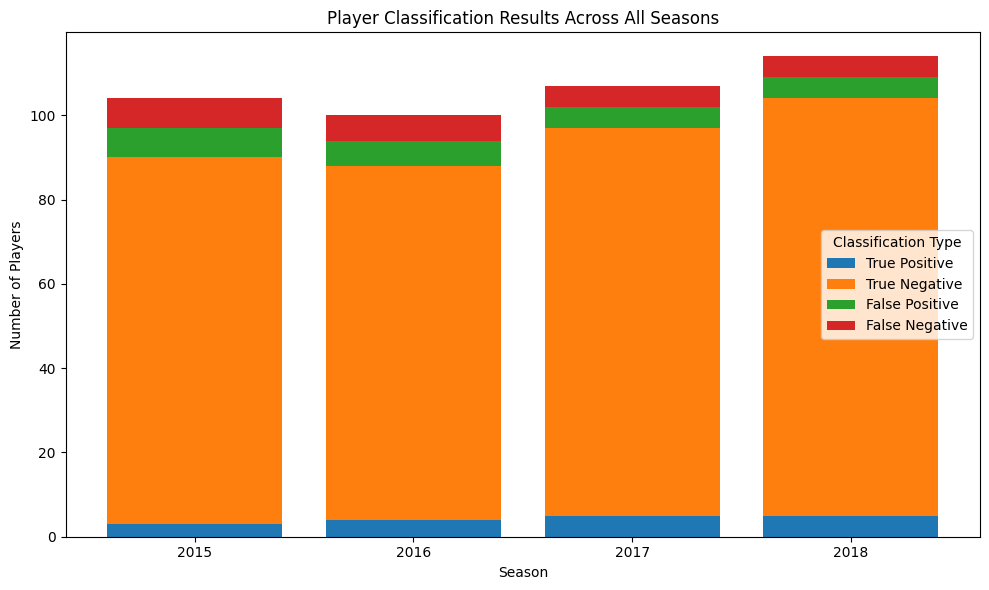

In [ ]:
# Prepare data for plotting
classification_labels = list(season_counts[next(iter(season_counts))].keys())
seasons = sorted(season_counts.keys())  # Sort seasons to maintain chronological order

# Prepare data for stacked bar chart
data_to_plot = {label: [season_counts[season][label] for season in seasons] for label in classification_labels}

# Create a stacked bar chart
plt.figure(figsize=(10, 6))
bar_bottoms = [0] * len(seasons)

for label in classification_labels:
    plt.bar(range(len(seasons)), data_to_plot[label], bottom=bar_bottoms, label=label)
    bar_bottoms = [bar_bottoms[i] + data_to_plot[label][i] for i in range(len(bar_bottoms))]

# Set x-ticks to be the years as integers
plt.xticks(range(len(seasons)), seasons)

plt.title('Player Classification Results Across All Seasons')
plt.xlabel('Season')
plt.ylabel('Number of Players')
plt.legend(title='Classification Type')
plt.tight_layout()
plt.show()

In [ ]:
# Ensure the Power Rating is correctly calculated

df_filtered_seasons['Final_Rank'] = df_filtered_seasons['Power Rating'].rank(ascending=False)

# Sort by Final Rank
final_ranked_players = df_filtered_seasons[['PLAYER NAME', 'Season', 'Power Rating', 'PR Top 10 Finish', 'FedexCup Regular Season Points', 'Top 10 Finish']]

# Get the unique seasons
unique_seasons = final_ranked_players['Season'].unique()

# Loop through each season and print the top 10 players
for season in unique_seasons:
    # Get the top 10 players by Power Rating for the current season
    top_10_by_power_rating = final_ranked_players[final_ranked_players['Season'] == season].nlargest(10, 'Power Rating')

    # Reset index for cleaner output
    top_10_by_power_rating.reset_index(drop=True, inplace=True)

    # Print the DataFrame for the current season by Power Rating
    print(f"\nTop 10 Players for the {season} Season (by Power Rating):")
    print(top_10_by_power_rating[['PLAYER NAME', 'Season', 'Power Rating', 'PR Top 10 Finish', 'FedexCup Regular Season Points', 'Top 10 Finish']])



Top 10 Players for the 2018 Season (by Power Rating):
       PLAYER NAME  Season  Power Rating  PR Top 10 Finish  \
0   Dustin Johnson    2018      4.692247                 1   
1    Brooks Koepka    2018      3.628352                 1   
2    Justin Thomas    2018      3.369795                 1   
3    Rickie Fowler    2018      3.169090                 1   
4    Jordan Spieth    2018      3.039798                 1   
5      Tiger Woods    2018      2.922704                 1   
6     Webb Simpson    2018      2.190888                 1   
7         Jon Rahm    2018      1.951214                 1   
8  Kevin Streelman    2018      1.920201                 1   
9      Joel Dahmen    2018      1.700441                 1   

   FedexCup Regular Season Points  Top 10 Finish  
0                          2717.0              1  
1                          2012.0              1  
2                          2634.0              1  
3                          1302.0              0  
4      

count     90.000000
mean      20.484880
std      128.839635
min     -226.988627
25%      -51.850561
50%        3.911911
75%       81.116912
max      810.189891
Name: Initial Power Rating, dtype: float64
Accuracy: 86.67%
Number of incorrectly classified players: 12 out of 90
          PLAYER NAME  PR Top 10 Finish  Top 10 Finish
415    Dustin Johnson                 0              1
174      Bubba Watson                 0              1
1029     Patrick Reed                 0              1
1057   Phil Mickelson                 0              1
1024  Patrick Cantlay                 0              1
1038   Patton Kizzire                 0              1
1020        Pat Perez                 1              0
141      Brian Harman                 1              0
575       Ian Poulter                 1              0
753     Jordan Spieth                 1              0
800   Kevin Streelman                 1              0
1233     Seamus Power                 1              0


<ipython-input-57-8bffe14e4bc0>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Weighted_Avg_Score'] = (
<ipython-input-55-fca9ab9009fc>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Weighted_SG'] = (
<ipython-input-61-332da91199b2>:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#retu

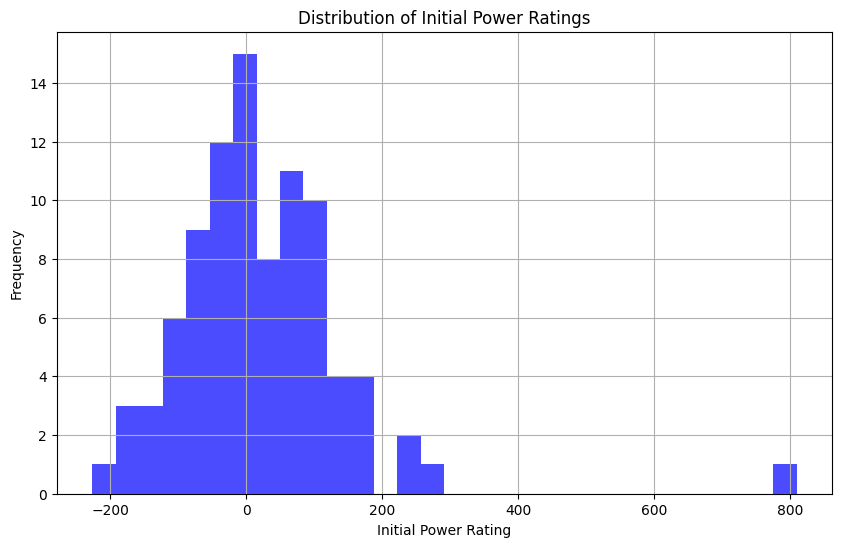

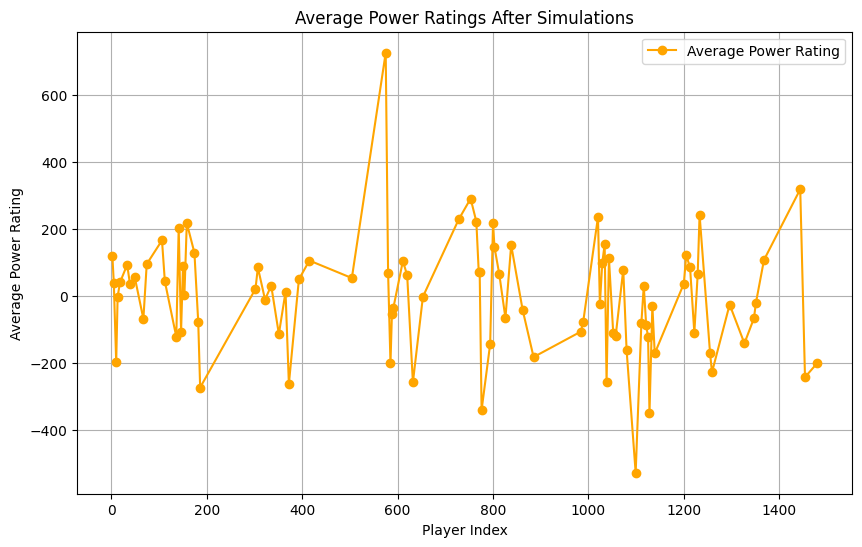

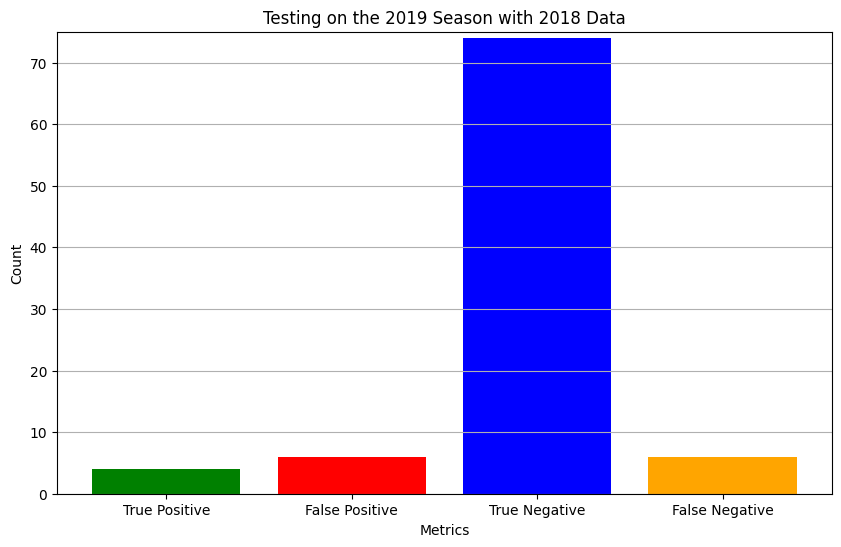

In [ ]:
# Create a set of player names from the 2019 season
players_2019 = set(df_ML[df_ML['Season'] == 2019]['PLAYER NAME'])

# Filter the dataset for the 2018 season where PLAYER NAME is in the set from 2019
df_test_season = df_ML[
    (df_ML['Season'] == 2018) &
    (df_ML['PLAYER NAME'].isin(players_2019)) &
    (df_ML['Total Birdies'] > 200)
]

# Define a function for checking rankings
def analyze_power_ratings(df, avg_feature_importance_dict, SG_feature_importance_dict, num_simulations=100, plot_name=''):
    """
    Compute weighted scores, calculate power ratings, run simulations,
    analyze the results, and generate visualizations.

    Parameters:
    - df: DataFrame containing player data.
    - avg_feature_importance_dict: Dictionary for weighted scoring.
    - SG_feature_importance_dict: Dictionary for SG scoring.
    - num_simulations: Number of simulations to run (default is 100).

    Returns:
    - DataFrame with results and accuracy information.
    """
    # Compute weighted scores
    df = compute_weighted_SA_score(df, avg_feature_importance_dict)
    df = compute_weighted_SG_score(df, SG_feature_importance_dict)

    # Calculate Power Rating
    df['Initial Power Rating'] = (
        df['Weighted_Avg_Score'] * zscore(df['Weighted_Avg_Score']) +
        df['Weighted_SG'] * zscore(df['Weighted_SG'])
    )

    # Analyze Power Rating to determine mean and variance for noise
    print(df['Initial Power Rating'].describe())

    # Determine mean and std dev for noise
    mean_noise = 0
    std_dev_power_rating = df['Initial Power Rating'].std()
    noise_std_dev = std_dev_power_rating * 10

    # Run simulations and store results
    simulated_power_ratings = np.zeros((len(df), num_simulations))

    for i in range(num_simulations):
        # Generate random noise for each player
        random_noise = np.random.normal(loc=mean_noise, scale=noise_std_dev, size=len(df))

        # Apply noise to the power ratings and store results
        simulated_power_ratings[:, i] = df['Initial Power Rating'] + random_noise

    # Calculate the average Power Rating over all simulations
    df['Avg Power Rating'] = np.mean(simulated_power_ratings, axis=1)

    # Assign percentiles based on the average Power Rating
    df = assign_top_10_buckets(df, 'Avg Power Rating', 'PR Top 10 Finish')

    # Calculate accuracy
    accuracy, incorrect_count, total_entries = calculate_accuracy_and_errors(df, 'PR Top 10 Finish', 'Top 10 Finish')
    print(f"Accuracy: {accuracy:.2f}%")
    print(f"Number of incorrectly classified players: {incorrect_count} out of {total_entries}")

    # Create a DataFrame to store relevant results
    results_df = df[['PLAYER NAME', 'PR Top 10 Finish', 'Top 10 Finish', 'FedexCup Regular Season Points']]

    # Filter to include only incorrectly classified players
    incorrect_classifications_df = results_df[
        results_df['PR Top 10 Finish'] != results_df['Top 10 Finish']
    ]

    # Sort the results by FedExCup Regular Season Points
    sorted_incorrect_classifications = incorrect_classifications_df.sort_values(by='FedexCup Regular Season Points', ascending=False)

    # Print the relevant columns
    print(sorted_incorrect_classifications[['PLAYER NAME', 'PR Top 10 Finish', 'Top 10 Finish']])

    # Visualizations

    # Histogram of Initial Power Ratings
    plt.figure(figsize=(10, 6))
    plt.hist(df['Initial Power Rating'], bins=30, alpha=0.7, color='blue')
    plt.title('Distribution of Initial Power Ratings')
    plt.xlabel('Initial Power Rating')
    plt.ylabel('Frequency')
    plt.grid()
    plt.show()

    # Line Plot of Average Power Ratings
    plt.figure(figsize=(10, 6))
    plt.plot(df['Avg Power Rating'], marker='o', linestyle='-', color='orange', label='Average Power Rating')
    plt.title('Average Power Ratings After Simulations')
    plt.xlabel('Player Index')
    plt.ylabel('Average Power Rating')
    plt.grid()
    plt.legend()
    plt.show()

    # Classification Metrics
    true_positive = df[(df['PR Top 10 Finish'] == 1) & (df['Top 10 Finish'] == 1)].shape[0]
    false_positive = df[(df['PR Top 10 Finish'] == 1) & (df['Top 10 Finish'] == 0)].shape[0]
    true_negative = df[(df['PR Top 10 Finish'] == 0) & (df['Top 10 Finish'] == 0)].shape[0]
    false_negative = df[(df['PR Top 10 Finish'] == 0) & (df['Top 10 Finish'] == 1)].shape[0]

    # Create a bar plot for the classification metrics
    metrics = ['True Positive', 'False Positive', 'True Negative', 'False Negative']
    values = [true_positive, false_positive, true_negative, false_negative]

    plt.figure(figsize=(10, 6))
    plt.bar(metrics, values, color=['green', 'red', 'blue', 'orange'])
    plt.title(plot_name)
    plt.ylabel('Count')
    plt.xlabel('Metrics')
    plt.ylim(0, max(values) + 1)
    plt.grid(axis='y')
    plt.show()

    return df

df_test_season = analyze_power_ratings(df_test_season, avg_feature_importance_dict, SG_feature_importance_dict, 100, 'Testing on the 2019 Season with 2018 Data')


count     121.000000
mean       19.601643
std       139.636261
min      -319.772523
25%       -56.696831
50%         8.197027
75%        81.284665
max      1040.711382
Name: Initial Power Rating, dtype: float64
Accuracy: 86.78%
Number of incorrectly classified players: 16 out of 121
           PLAYER NAME  PR Top 10 Finish  Top 10 Finish
886        Matt Kuchar                 0              1
505      Gary Woodland                 0              1
1025   Patrick Cantlay                 0              1
1044        Paul Casey                 0              1
1445      Webb Simpson                 0              1
729           Jon Rahm                 0              1
1081     Rickie Fowler                 0              1
308        Chez Reavie                 0              1
766      Justin Thomas                 1              0
1298        Sungjae Im                 1              0
187           C.T. Pan                 1              0
366          Danny Lee                 1    

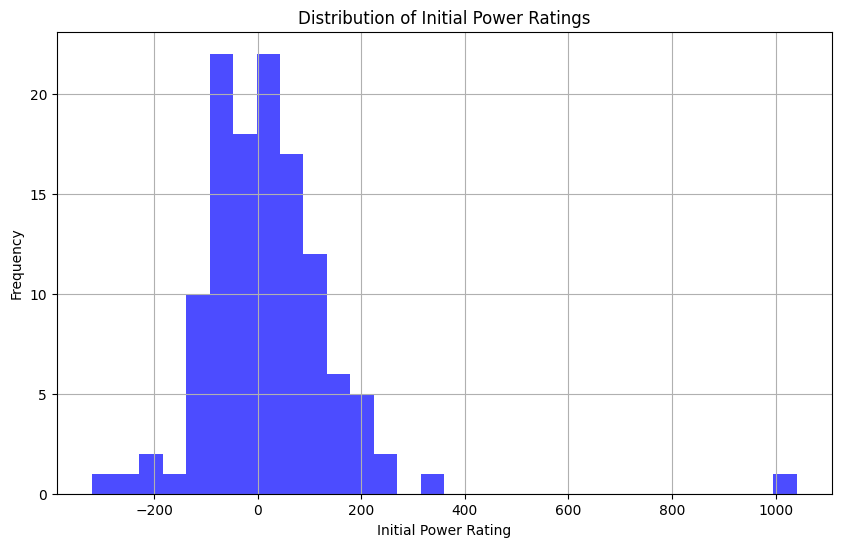

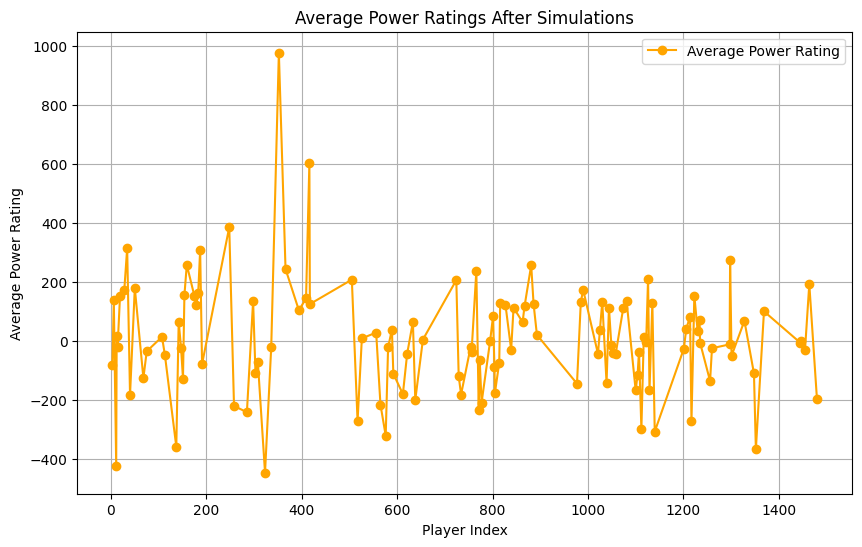

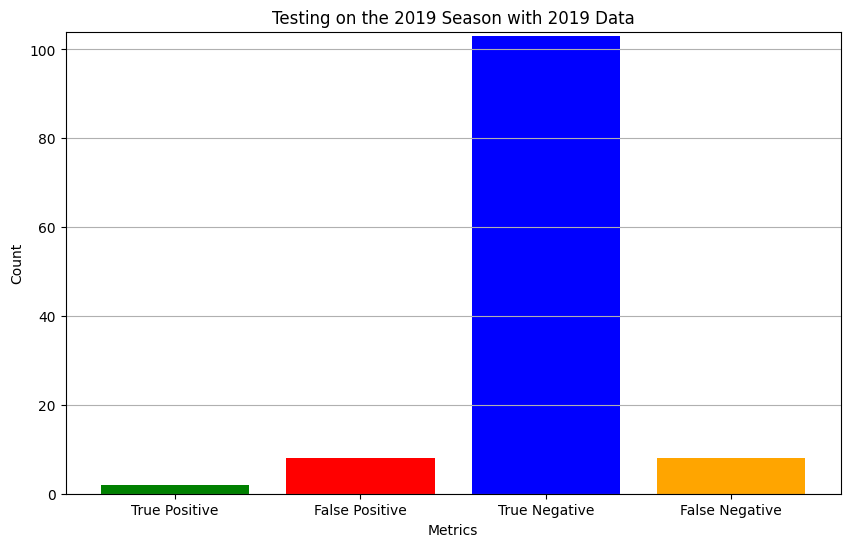

In [ ]:
# Filter the dataset for the 2019 season
df_test_season_2 = df_ML[(df_ML['Season'] == 2019) & (df_ML['Total Birdies'] > 200)].copy()

df_test_season_2 = analyze_power_ratings(df_test_season_2, avg_feature_importance_dict, SG_feature_importance_dict, 100, 'Testing on the 2019 Season with 2019 Data')

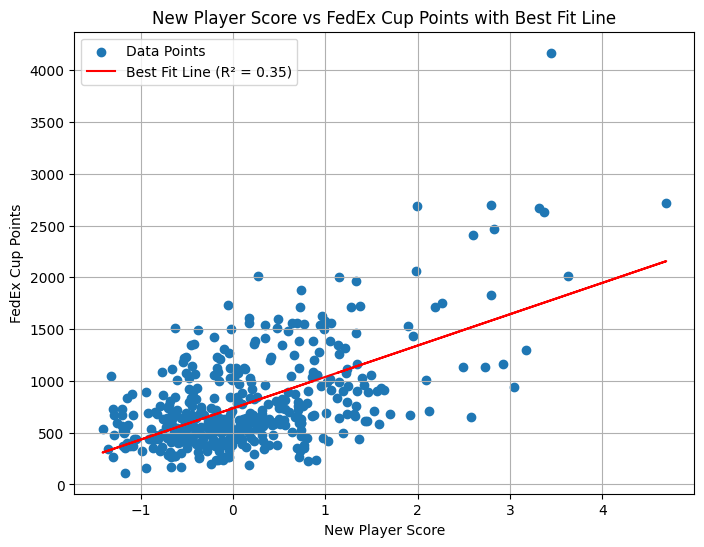

0.3454830528169738

In [ ]:
# Prepare data for linear regression
X_clean = df_filtered_seasons['Power Rating'].values.reshape(-1, 1)
y_clean = df_filtered_seasons['FedexCup Regular Season Points'].values

# Fit the linear regression model
model = LinearRegression()
model.fit(X_clean, y_clean)

# Predict values for the best fit line
y_pred_clean = model.predict(X_clean)

# Calculate the R^2 value
r_squared_clean = model.score(X_clean, y_clean)

# Plot the data points and the best fit line
plt.figure(figsize=(8, 6))
plt.scatter(X_clean, y_clean, label='Data Points')
plt.plot(X_clean, y_pred_clean, color='red', label=f'Best Fit Line (R² = {r_squared_clean:.2f})')
plt.title('New Player Score vs FedEx Cup Points with Best Fit Line')
plt.xlabel('New Player Score')
plt.ylabel('FedEx Cup Points')
plt.grid(True)
plt.legend()
plt.show()

# Output the R² value
r_squared_clean


We see fairly muddled results in the middle of our analysis - which makes sense. However, we see that towards the highest performing golfers, there is a clear pattern. Let's examine the % of players that had a score of 1.5 or higher that finish > 750 FedEx points!

# 7. Sensitivity Analysis

Let's see what happens when we change the weight coefficients on both the SG: total and the Scoring Average relative ranks. Will be interesting to see if one of the metrics is better off without the other from a predictive standpoint, or if our weight now is not optimal.

In [ ]:
# Create a set of player names from the 2019 season
players_2019 = set(df_ML[df_ML['Season'] == 2019]['PLAYER NAME'])

# Filter the dataset for the 2018 season where PLAYER NAME is in the set from 2019
df_test_season = df_ML[(df_ML['Season'] == 2018) & (df_ML['PLAYER NAME'].isin(players_2019)) & (df_ML['Total Birdies'] > 200)]

# Calculate z-scores for the relevant columns
df_test_season['Z_SG_Total'] = zscore(df_test_season['SG: Total'])
df_test_season['Z_Scoring_Avg'] = zscore(df_test_season['Scoring Average'])

# Sensitize weighted averages for each combination of coefficients
results = []

for w1 in np.arange(0, 1.1, 0.1):
    w2 = 1 - w1
    df_test_season['Weighted_Avg_Power_Rating'] = (
        w1 * df_test_season['Z_SG_Total'] +
        w2 * df_test_season['Z_Scoring_Avg']
    )

    # Calculate initial power rating using sensitized weights
    df_test_season['Initial Power Rating'] = df_test_season['Weighted_Avg_Power_Rating']

    # Without random noise, use the Initial Power Rating directly as the Power Rating
    df_test_season['Power Rating'] = df_test_season['Initial Power Rating']

    # Assign percentiles based on the Power Rating
    df_test_season = assign_top_10_buckets(df_test_season, 'Power Rating', 'PR Top 10 Finish')

    # Calculate accuracy
    accuracy, incorrect_count, _ = calculate_accuracy_and_errors(df_test_season, 'PR Top 10 Finish', 'Top 10 Finish')

    # Store the results for this weight combination
    results.append({
        'Weight SG Total': w1,
        'Weight Scoring Avg': w2,
        'Accuracy': accuracy,
        'Incorrect Classifications': incorrect_count
    })

# Create a DataFrame to store and analyze the results of different weight combinations
results_df = pd.DataFrame(results)

<ipython-input-64-fc4295544a26>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_season['Z_SG_Total'] = zscore(df_test_season['SG: Total'])
<ipython-input-64-fc4295544a26>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_season['Z_Scoring_Avg'] = zscore(df_test_season['Scoring Average'])
<ipython-input-64-fc4295544a26>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the

In [ ]:
results_df

,Weight SG Total,Weight Scoring Avg,Accuracy,Incorrect Classifications
0,0.0,1.0,77.777778,20
1,0.1,0.9,77.777778,20
2,0.2,0.8,77.777778,20
3,0.3,0.7,77.777778,20
4,0.4,0.6,77.777778,20
5,0.5,0.5,77.777778,20
6,0.6,0.4,84.444444,14
7,0.7,0.3,88.888889,10
8,0.8,0.2,88.888889,10
9,0.9,0.1,91.111111,8


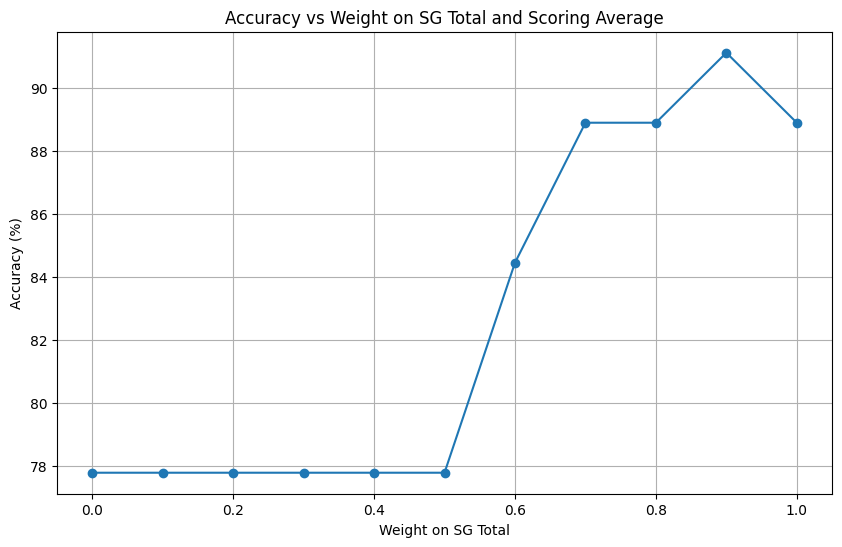

In [ ]:
# Plot the accuracy vs. weight combinations
plt.figure(figsize=(10, 6))
plt.plot(results_df['Weight SG Total'], results_df['Accuracy'], marker='o')
plt.title('Accuracy vs Weight on SG Total and Scoring Average')
plt.xlabel('Weight on SG Total')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.show()

We see a maximum accuracy at a 90% weighting towards SG: Total! Funny, this is the inverse of the "90% mental" addage...

In [ ]:
# Set the weight to 0.9 for SG: Total and 0.1 for Scoring Average
w1 = 0.9
w2 = 1 - w1

df_test_season['Weighted_Avg_Power_Rating'] = (
    w1 * df_test_season['Z_SG_Total'] +
    w2 * df_test_season['Z_Scoring_Avg']
)

# Calculate initial power rating using the weighted averages
df_test_season['Initial Power Rating'] = df_test_season['Weighted_Avg_Power_Rating']

# Assign percentiles based on the Power Rating
df_test_season = assign_top_10_buckets(df_test_season, 'Initial Power Rating', 'PR Top 10 Finish')

# Classification Metrics (SG: Total Weight = 0.9)
true_positive = df_test_season[(df_test_season['PR Top 10 Finish'] == 1) &
                                (df_test_season['Top 10 Finish'] == 1)].shape[0]
false_positive = df_test_season[(df_test_season['PR Top 10 Finish'] == 1) &
                                 (df_test_season['Top 10 Finish'] == 0)].shape[0]
true_negative = df_test_season[(df_test_season['PR Top 10 Finish'] == 0) &
                                (df_test_season['Top 10 Finish'] == 0)].shape[0]
false_negative = df_test_season[(df_test_season['PR Top 10 Finish'] == 0) &
                                 (df_test_season['Top 10 Finish'] == 1)].shape[0]

<ipython-input-67-aa0fb92e22d0>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_season['Weighted_Avg_Power_Rating'] = (
<ipython-input-67-aa0fb92e22d0>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_season['Initial Power Rating'] = df_test_season['Weighted_Avg_Power_Rating']
<ipython-input-39-3f6980da649e>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the document

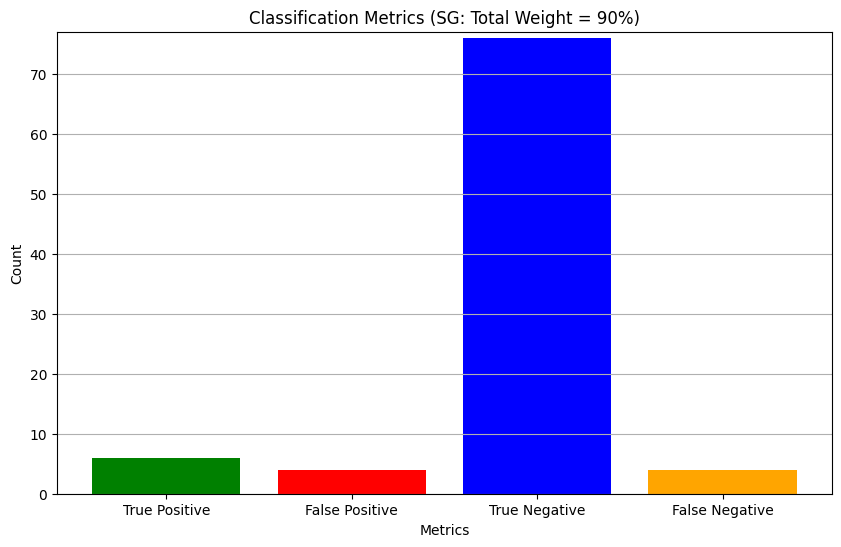

In [ ]:
# Bar Plot of Classification Metrics
metrics = ['True Positive', 'False Positive', 'True Negative', 'False Negative']
values = [true_positive, false_positive, true_negative, false_negative]

plt.figure(figsize=(10, 6))
plt.bar(metrics, values, color=['green', 'red', 'blue', 'orange'])
plt.title('Classification Metrics (SG: Total Weight = 90%)')
plt.ylabel('Count')
plt.xlabel('Metrics')
plt.ylim(0, max(values) + 1)
plt.grid(axis='y')
plt.show()

Now, let's look at a simulatuon **with** noise. We will run this 100 different times, and look at the average accuracy across different weights towards SG: Total.

In [ ]:
# Create a set of player names from the 2019 season
players_2019 = set(df_ML[df_ML['Season'] == 2019]['PLAYER NAME'])

# Filter the dataset for the 2018 season where PLAYER NAME is in the set from 2019
df_test_season = df_ML[(df_ML['Season'] == 2018) & (df_ML['PLAYER NAME'].isin(players_2019)) & (df_ML['Total Birdies'] > 200)]

# Calculate z-scores for the relevant columns
df_test_season['Z_SG_Total'] = zscore(df_test_season['SG: Total'])
df_test_season['Z_Scoring_Avg'] = zscore(df_test_season['Scoring Average'])

# Run 100 iterations and store the average accuracy for each weight combination
iterations = 100
all_results = []

for iteration in range(iterations):
    results = []

    for w1 in np.arange(0, 1.1, 0.1):
        w2 = 1 - w1
        df_test_season['Weighted_Avg_Power_Rating'] = (
            w1 * df_test_season['Z_SG_Total'] +
            w2 * df_test_season['Z_Scoring_Avg']
        )

        # Calculate initial power rating using sensitized weights
        df_test_season['Initial Power Rating'] = df_test_season['Weighted_Avg_Power_Rating']

        # Analyze Power Rating to determine mean and variance for noise
        mean_noise = 0
        std_dev_power_rating = df_test_season['Initial Power Rating'].std()
        noise_std_dev = std_dev_power_rating * .5

        # Generate random noise for each player (one value per player)
        random_noise = np.random.normal(loc=mean_noise, scale=noise_std_dev, size=len(df_test_season))

        # Apply noise to the power ratings
        df_test_season['Power Rating'] = df_test_season['Initial Power Rating'] + random_noise

        # Assign percentiles based on the average Power Rating
        df_test_season = assign_top_10_buckets(df_test_season, 'Power Rating', 'PR Top 10 Finish')

        # Calculate accuracy
        accuracy, incorrect_count, _ = calculate_accuracy_and_errors(df_test_season, 'PR Top 10 Finish', 'Top 10 Finish')

        # Store the results for this weight combination
        results.append({
            'Weight SG Total': w1,
            'Weight Scoring Avg': w2,
            'Accuracy': accuracy
        })

    all_results.append(results)

# Average the accuracy over all iterations
accuracy_means = np.mean([pd.DataFrame(res)['Accuracy'] for res in all_results], axis=0)
weights_sg_total = np.arange(0, 1.1, 0.1)

Streaming output truncated to the last 5000 lines.
See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_season['Power Rating'] = df_test_season['Initial Power Rating'] + random_noise
<ipython-input-39-3f6980da649e>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[new_col_name] = 0
<ipython-input-69-4ff20296a73c>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_season['Weighted_Avg_Power_Rating'] = (


[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
[77.86666667 77.8        77.82222222 77.8        77.77777778 78.35555556
 85.02222222 87.42222222 88.33333333 88.37777778 89.26666667]


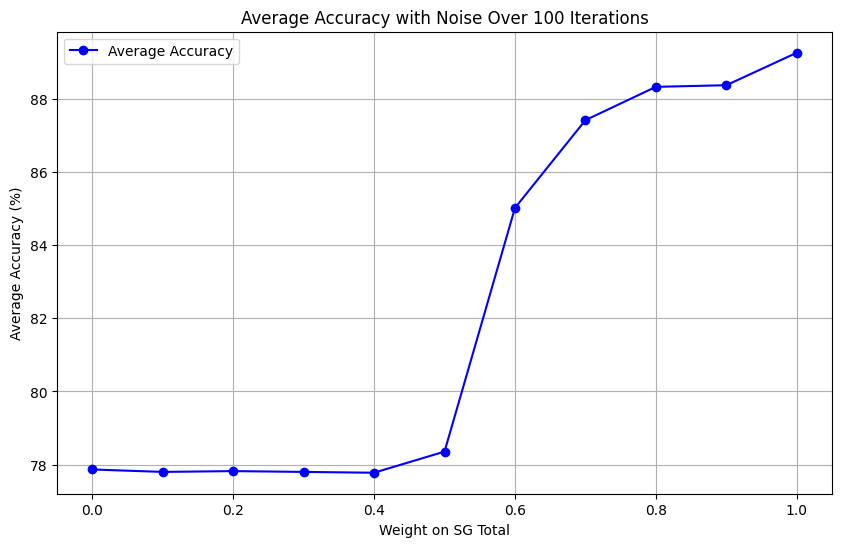

In [ ]:
print(weights_sg_total)
print(accuracy_means)

# Plot the average accuracy over 100 iterations
plt.figure(figsize=(10, 6))
plt.plot(weights_sg_total, accuracy_means, marker='o', linestyle='-', color='blue', label='Average Accuracy')
plt.title('Average Accuracy with Noise Over 100 Iterations')
plt.xlabel('Weight on SG Total')
plt.ylabel('Average Accuracy (%)')
plt.grid(True)
plt.legend()
plt.show()